<a href="https://colab.research.google.com/github/Altaieb-Mohammed/lab_2corse/blob/master/lab2_3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

import pandas as pd
url = "https://raw.githubusercontent.com/Altaieb-Mohammed/lab_2corse/master/final_inheritanc.csv"
df = pd.read_csv(url)

# Basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (16665, 19)

Column Names:
['estate', 'debts', 'wills', 'husband', 'wives', 'father', 'mother', 'sons', 'daughters', 'brothers_m', 'sisters_m', 'grandfather', 'grandmother', 'share_husband', 'share_wife', 'share_father', 'share_mother', 'share_sons', 'share_daughters']

First few rows:
   estate  debts     wills  husband  wives  father  mother  sons  daughters  \
0  170040  22540   2663.76        1      0       1       1     1          1   
1  181741  10376  14674.26        0      0       1       1     1          1   
2  158290   2848   2591.00        1      0       0       0     1          0   
3  101742  21068  12245.39        0      1       1       1     0          1   
4  143847  19321  25961.21        1      0       1       0     1          0   

   brothers_m  sisters_m  grandfather  grandmother  share_husband  share_wife  \
0           1          1            0            1       36209.06        0.00   
1           1          1            1            1           

In [ ]:
#2 Calculate net estate
df['net_estate'] = df['estate'] - df['debts'] - df['wills']

# Check if distributions sum to net estate
df['total_distributed'] = df[['share_husband', 'share_wife', 'share_father',
                               'share_mother', 'share_sons', 'share_daughters']].sum(axis=1)

# Calculate difference
df['distribution_diff'] = df['net_estate'] - df['total_distributed']
print("\nDistribution Accuracy Check:")
print(f"Mean difference: {df['distribution_diff'].mean():.2f}")
print(f"Max difference: {df['distribution_diff'].max():.2f}")
print(f"Min difference: {df['distribution_diff'].min():.2f}")


Distribution Accuracy Check:
Mean difference: 0.00
Max difference: 0.02
Min difference: -0.02


In [ ]:
# 3Descriptive statistics for numerical columns
print("\nDescriptive Statistics - Estate and Debts:")
print(df[['estate', 'debts', 'wills', 'net_estate']].describe())

# Frequency of different family members
print("\nFrequency of Family Members Present:")
family_members = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters',
                  'brothers_m', 'sisters_m', 'grandfather', 'grandmother']
for member in family_members:
    present_count = df[member].sum()
    percentage = (present_count / len(df)) * 100
    print(f"{member}: {present_count} cases ({percentage:.1f}%)")


Descriptive Statistics - Estate and Debts:
              estate         debts         wills     net_estate
count   16665.000000  16665.000000  16665.000000   16665.000000
mean   124878.406061  18889.544254  17649.324434   88339.537372
std     42981.668867  13245.773120  12605.104226   33580.560664
min     50007.000000      0.000000      4.420000   24821.270000
25%     87749.000000   8190.000000   7490.290000   60644.280000
50%    124642.000000  16382.000000  15199.490000   86374.440000
75%    161775.000000  27377.000000  25609.200000  112751.500000
max    199997.000000  59601.000000  65673.560000  194756.900000

Frequency of Family Members Present:
husband: 8667 cases (52.0%)
wives: 2383 cases (14.3%)
father: 8799 cases (52.8%)
mother: 8693 cases (52.2%)
sons: 15123 cases (90.7%)
daughters: 12641 cases (75.9%)
brothers_m: 11026 cases (66.2%)
sisters_m: 11105 cases (66.6%)
grandfather: 8253 cases (49.5%)
grandmother: 8199 cases (49.2%)


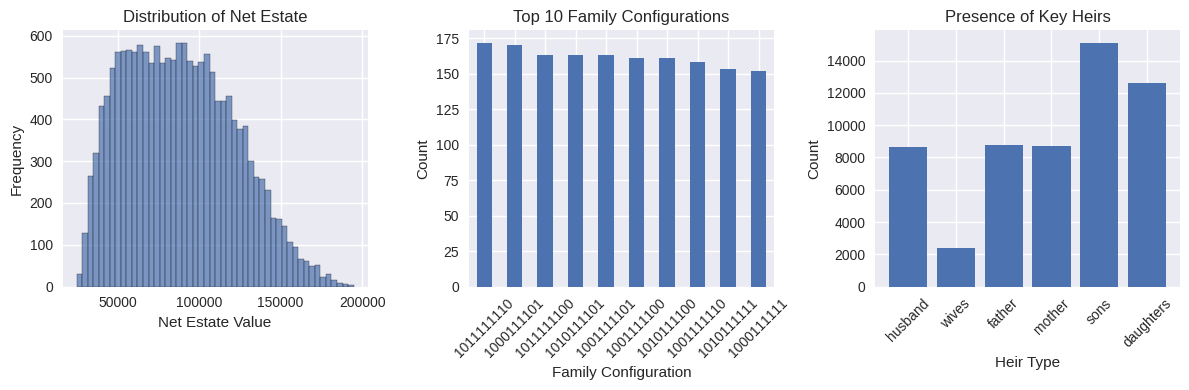

In [ ]:
# Set up the plotting style
plt.style.use('seaborn-v0_8')

# 4Plot 1: Distribution of net estate
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df['net_estate'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Net Estate')
plt.xlabel('Net Estate Value')
plt.ylabel('Frequency')

# Plot 2: Most common family configurations
plt.subplot(1, 3, 2)
# Create a simple family configuration identifier
df['family_config'] = df[family_members].apply(lambda x: ''.join(x.astype(str)), axis=1)
top_configs = df['family_config'].value_counts().head(10)
top_configs.plot(kind='bar')
plt.title('Top 10 Family Configurations')
plt.xlabel('Family Configuration')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 3: Presence of key heirs
plt.subplot(1, 3, 3)
key_heirs = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters']
presence_counts = [df[heir].sum() for heir in key_heirs]
plt.bar(key_heirs, presence_counts)
plt.title('Presence of Key Heirs')
plt.xlabel('Heir Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Correlation between Net Estate and Heir Shares:
net_estate         1.000000
share_sons         0.589928
share_daughters    0.388660
share_mother       0.344358
share_husband      0.331610
share_father       0.303480
share_wife         0.150308
Name: net_estate, dtype: float64


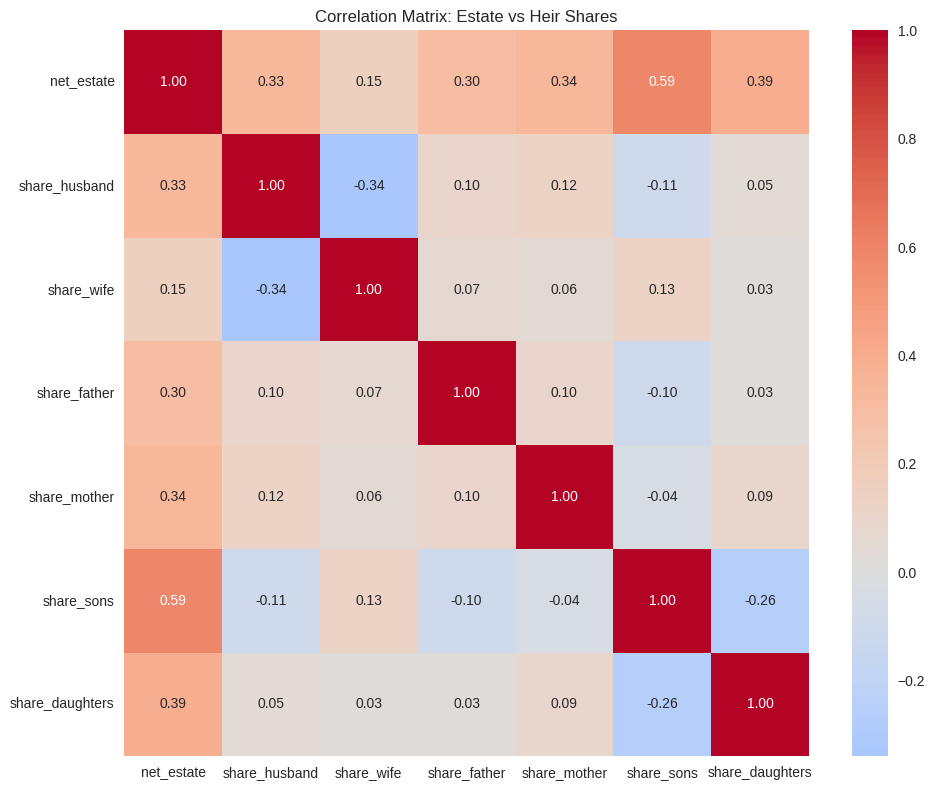

In [ ]:
# 5Correlation between estate size and heir shares
print("\nCorrelation between Net Estate and Heir Shares:")
correlation_matrix = df[['net_estate', 'share_husband', 'share_wife', 'share_father',
                         'share_mother', 'share_sons', 'share_daughters']].corr()
print(correlation_matrix['net_estate'].sort_values(ascending=False))

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Estate vs Heir Shares')
plt.tight_layout()
plt.show()

LAB 3: PATTERN ANALYSIS AND HEIRSHIP RULES

In [ ]:
# 1Group by presence of key heirs
print("\n=== Inheritance Patterns by Family Composition ===")

# Case 1: When husband is present vs absent
husband_cases = df.groupby('husband').agg({
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean',
    'net_estate': 'mean'
}).round(2)

print("\n1. Husband Present (1) vs Absent (0):")
print(husband_cases)

# Case 2: When sons are present vs absent
print("\n2. Average Share Distribution by Sons Presence:")
sons_analysis = df.groupby('sons').agg({
    'share_sons': 'mean',
    'share_daughters': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean'
}).round(2)
print(sons_analysis)

# Case 3: Father and Mother combinations
print("\n3. Father and Mother Presence Combinations:")
parent_combinations = df.groupby(['father', 'mother']).size().reset_index(name='count')
parent_combinations['percentage'] = (parent_combinations['count'] / len(df) * 100).round(1)
print(parent_combinations)


=== Inheritance Patterns by Family Composition ===

1. Husband Present (1) vs Absent (0):
         share_husband  share_wife  share_father  share_mother  share_sons  \
husband                                                                      
0                 0.00     3334.72       8376.13       7629.81    49956.78   
1             21927.86        0.00       7783.53       7637.55    33033.18   

         share_daughters  net_estate  
husband                               
0               19434.88    88732.32  
1               17594.96    87977.07  

2. Average Share Distribution by Sons Presence:
      share_sons  share_daughters  share_father  share_mother
sons                                                         
0           0.00         45481.67      14912.86      10472.39
1       45351.64         15724.59       7370.00       7344.40

3. Father and Mother Presence Combinations:
   father  mother  count  percentage
0       0       0   3766        22.6
1       0       1   4100

CALCULATING SHARE PERCENTAGES
✅ Found all required columns
✅ Total records: 16665
✅ Net estate range: $24,821 to $194,757

----------------------------------------
Calculating percentage shares...
  share_husband: 16665 records calculated (0 zero/negative net estate)
  share_wife: 16665 records calculated (0 zero/negative net estate)
  share_father: 16665 records calculated (0 zero/negative net estate)
  share_mother: 16665 records calculated (0 zero/negative net estate)
  share_sons: 16665 records calculated (0 zero/negative net estate)
  share_daughters: 16665 records calculated (0 zero/negative net estate)

----------------------------------------
Calculating average percentages (when heir is present)...
  husband: 24.9% (based on 8667 cases, range: 20.0%-50.0%)
  wife: 12.6% (based on 2383 cases, range: 11.1%-25.0%)
  father: 17.3% (based on 8799 cases, range: 13.3%-100.0%)
  mother: 16.5% (based on 8693 cases, range: 13.3%-33.3%)
  sons: 51.3% (based on 15123 cases, range: 16.7%-1

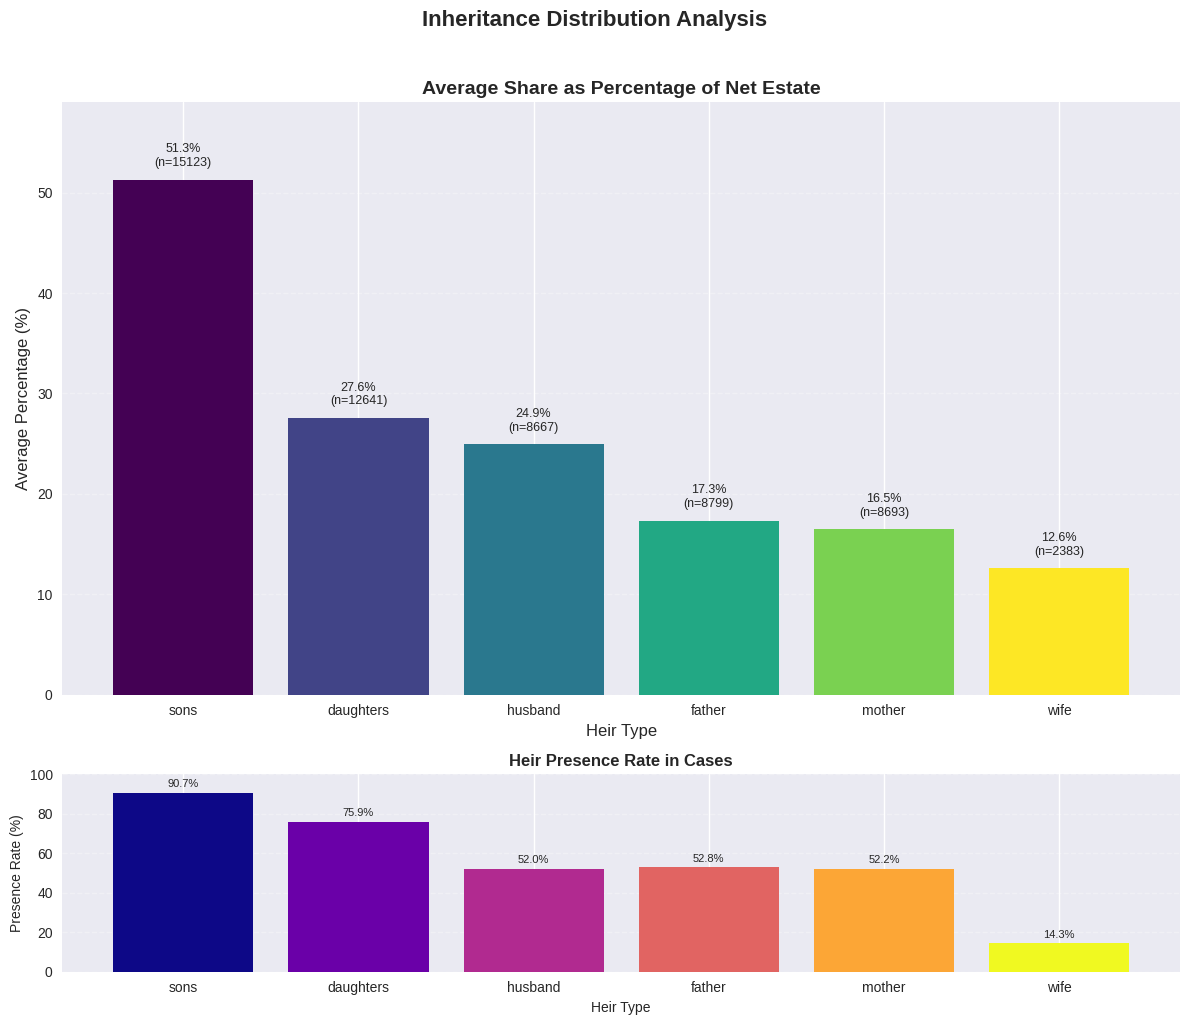

In [ ]:
# Enhanced version with error handling and validation

def calculate_share_percentages(df):
    """
    Calculate percentage shares for each heir type with comprehensive error handling

    Parameters:
    df (DataFrame): Input dataframe containing inheritance data

    Returns:
    tuple: (avg_percentages dictionary, boolean success flag, error_message)
    """

    # Validate input dataframe
    if df.empty:
        print("❌ Error: Dataframe is empty!")
        return None, False, "Empty dataframe"

    print("=" * 60)
    print("CALCULATING SHARE PERCENTAGES")
    print("=" * 60)

    # Define required columns
    required_columns = ['net_estate']
    share_columns = ['share_husband', 'share_wife', 'share_father', 'share_mother',
                     'share_sons', 'share_daughters']

    # Check for required columns
    missing_columns = [col for col in required_columns + share_columns
                      if col not in df.columns]

    if missing_columns:
        print(f"❌ Missing columns: {missing_columns}")
        print(f"✅ Available columns: {df.columns.tolist()}")
        return None, False, f"Missing columns: {missing_columns}"

    print(f"✅ Found all required columns")
    print(f"✅ Total records: {len(df)}")
    print(f"✅ Net estate range: ${df['net_estate'].min():,.0f} to ${df['net_estate'].max():,.0f}")

    # Calculate percentage shares with validation
    print("\n" + "-" * 40)
    print("Calculating percentage shares...")

    for col in share_columns:
        # Create percentage column name
        pct_col = f'{col}_pct'

        # Calculate percentage only for valid net_estate values
        mask_valid = df['net_estate'] > 0
        if mask_valid.any():
            df[pct_col] = 0.0  # Initialize with zeros

            # Calculate for valid rows
            df.loc[mask_valid, pct_col] = (df.loc[mask_valid, col] /
                                          df.loc[mask_valid, 'net_estate']) * 100
        else:
            print(f"⚠️ Warning: No valid net_estate values (> 0) for {col}")
            df[pct_col] = 0.0

        # Track calculation statistics
        n_calculated = mask_valid.sum()
        print(f"  {col}: {n_calculated} records calculated ({len(df) - n_calculated} zero/negative net estate)")

    # Get average percentages with detailed statistics
    print("\n" + "-" * 40)
    print("Calculating average percentages (when heir is present)...")

    avg_percentages = {}
    heir_statistics = {}

    for col in share_columns:
        heir_name = col.replace('share_', '')
        pct_col = f'{col}_pct'

        # Create mask for when heir is present (value > 0)
        presence_mask = df[col] > 0

        if presence_mask.any():
            # Calculate statistics
            n_present = presence_mask.sum()
            avg_pct = df.loc[presence_mask, pct_col].mean()
            min_pct = df.loc[presence_mask, pct_col].min()
            max_pct = df.loc[presence_mask, pct_col].max()
            std_pct = df.loc[presence_mask, pct_col].std()

            avg_percentages[col] = {
                'average': avg_pct,
                'n_cases': n_present,
                'min': min_pct,
                'max': max_pct,
                'std': std_pct
            }

            heir_statistics[heir_name] = {
                'presence_rate': (n_present / len(df)) * 100,
                'n_cases': n_present
            }

            print(f"  {heir_name}: {avg_pct:.1f}% (based on {n_present} cases, "
                  f"range: {min_pct:.1f}%-{max_pct:.1f}%)")
        else:
            print(f"  {heir_name}: No cases found (never present in data)")
            avg_percentages[col] = {'average': 0, 'n_cases': 0}

    return avg_percentages, heir_statistics, True, "Success"

def display_results(avg_percentages, heir_statistics):
    """
    Display formatted results and statistics
    """
    print("\n" + "=" * 60)
    print("AVERAGE SHARES AS PERCENTAGE OF NET ESTATE")
    print("=" * 60)

    # Sort by average percentage (descending)
    sorted_heirs = sorted([(col, stats['average'])
                          for col, stats in avg_percentages.items()
                          if stats['n_cases'] > 0],
                         key=lambda x: x[1],
                         reverse=True)

    print("\n📊 Ranking by Average Share:")
    print("-" * 50)
    for i, (col, avg_pct) in enumerate(sorted_heirs, 1):
        heir_name = col.replace('share_', '')
        stats = avg_percentages[col]
        heir_stats = heir_statistics[heir_name]

        print(f"{i:2d}. {heir_name:12s}: {avg_pct:6.1f}% "
              f"(n={stats['n_cases']:3d}, "
              f"presence: {heir_stats['presence_rate']:5.1f}%, "
              f"range: {stats['min']:.1f}%-{stats['max']:.1f}%)")

    # Display summary statistics
    print("\n" + "-" * 50)
    print("📈 SUMMARY STATISTICS:")
    print("-" * 50)

    total_cases = sum(stats['n_cases'] for stats in avg_percentages.values())
    print(f"Total heir cases analyzed: {total_cases}")

    # Find most and least common heirs
    most_common = max(heir_statistics.items(), key=lambda x: x[1]['n_cases'])
    least_common = min(heir_statistics.items(), key=lambda x: x[1]['n_cases'])

    print(f"Most common heir: {most_common[0]} ({most_common[1]['n_cases']} cases)")
    print(f"Least common heir: {least_common[0]} ({least_common[1]['n_cases']} cases)")

def create_enhanced_visualization(avg_percentages, heir_statistics):
    """
    Create enhanced visualization with better formatting
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Filter out heirs with no cases
    valid_heirs = [(col, stats) for col, stats in avg_percentages.items()
                  if stats['n_cases'] > 0]

    if not valid_heirs:
        print("⚠️ No valid data for visualization")
        return

    # Prepare data
    heir_names = [col.replace('share_', '') for col, _ in valid_heirs]
    percentages = [stats['average'] for _, stats in valid_heirs]
    n_cases = [stats['n_cases'] for _, stats in valid_heirs]
    presence_rates = [heir_statistics[name]['presence_rate'] for name in heir_names]

    # Sort by percentage
    sorted_indices = np.argsort(percentages)[::-1]
    heir_names = [heir_names[i] for i in sorted_indices]
    percentages = [percentages[i] for i in sorted_indices]
    n_cases = [n_cases[i] for i in sorted_indices]
    presence_rates = [presence_rates[i] for i in sorted_indices]

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10),
                                   gridspec_kw={'height_ratios': [3, 1]})

    # Main bar chart
    bars = ax1.bar(heir_names, percentages,
                   color=plt.cm.viridis(np.linspace(0, 1, len(heir_names))))
    ax1.set_title('Average Share as Percentage of Net Estate', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Heir Type', fontsize=12)
    ax1.set_ylabel('Average Percentage (%)', fontsize=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_ylim(0, max(percentages) * 1.15)

    # Add value labels with case count
    for bar, pct, n in zip(bars, percentages, n_cases):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + max(percentages)*0.02,
                f'{pct:.1f}%\n(n={n})',
                ha='center', va='bottom', fontsize=9)

    # Secondary bar chart for presence rates
    ax2.bar(heir_names, presence_rates,
            color=plt.cm.plasma(np.linspace(0, 1, len(heir_names))))
    ax2.set_title('Heir Presence Rate in Cases', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Heir Type', fontsize=10)
    ax2.set_ylabel('Presence Rate (%)', fontsize=10)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.set_ylim(0, 100)

    # Add value labels for presence rates
    for i, (bar, rate) in enumerate(zip(ax2.patches, presence_rates)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=8)

    # Adjust layout and display
    plt.suptitle('Inheritance Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    # Save figure
    try:
        plt.savefig('inheritance_analysis.png', dpi=300, bbox_inches='tight')
        print("✅ Visualization saved as 'inheritance_analysis.png'")
    except Exception as e:
        print(f"⚠️ Could not save figure: {e}")

    plt.show()

# Main execution with error handling
def main():
    """
    Main execution function with comprehensive error handling
    """
    try:
        # Calculate percentages
        result = calculate_share_percentages(df)

        if result[2]:  # Check success flag
            avg_percentages, heir_statistics, success, message = result

            # Display results
            display_results(avg_percentages, heir_statistics)

            # Create visualization
            create_enhanced_visualization(avg_percentages, heir_statistics)

            # Return data for further analysis if needed
            return {
                'avg_percentages': avg_percentages,
                'heir_statistics': heir_statistics,
                'success': success,
                'message': message
            }
        else:
            print(f"\n❌ Analysis failed: {result[3]}")
            return None

    except KeyError as e:
        print(f"\n❌ KeyError: {e}")
        print(f"Available columns: {df.columns.tolist()}")
        print("\nTroubleshooting tips:")
        print("1. Check column names in your data")
        print("2. Verify the data has been loaded correctly")
        print("3. Ensure 'net_estate' column exists")

    except ZeroDivisionError:
        print("\n❌ Division by zero error")
        print("Check for zero or negative values in 'net_estate'")

    except Exception as e:
        print(f"\n❌ Unexpected error: {type(e).__name__}: {e}")

    return None

# Execute the analysis
if __name__ == "__main__":
    analysis_results = main()

In [ ]:
print("\n=== Special Cases Analysis ===")

# 3Case A: Only sons and daughters (no parents, spouse)
case_a = df[(df['sons'] == 1) & (df['daughters'] == 1) &
            (df['father'] == 0) & (df['mother'] == 0) &
            (df['husband'] == 0) & (df['wives'] == 0)]

if len(case_a) > 0:
    print(f"\nA. Only Sons and Daughters: {len(case_a)} cases")
    print(f"   Average sons share: {case_a['share_sons'].mean():.2f}")
    print(f"   Average daughters share: {case_a['share_daughters'].mean():.2f}")
    print(f"   Sons:Daughters ratio: {(case_a['share_sons']/case_a['share_daughters']).mean():.2f}:1")

# Case B: Husband and wife only
case_b = df[(df['husband'] == 1) & (df['wives'] == 1) &
            (df['sons'] == 0) & (df['daughters'] == 0) &
            (df['father'] == 0) & (df['mother'] == 0)]

if len(case_b) > 0:
    print(f"\nB. Husband and Wife Only: {len(case_b)} cases")
    print(f"   Average husband share: {case_b['share_husband'].mean():.2f}")
    print(f"   Average wife share: {case_b['share_wife'].mean():.2f}")

# Case C: Father and mother only
case_c = df[(df['father'] == 1) & (df['mother'] == 1) &
            (df['sons'] == 0) & (df['daughters'] == 0) &
            (df['husband'] == 0) & (df['wives'] == 0)]

if len(case_c) > 0:
    print(f"\nC. Father and Mother Only: {len(case_c)} cases")
    print(f"   Average father share: {case_c['share_father'].mean():.2f}")
    print(f"   Average mother share: {case_c['share_mother'].mean():.2f}")


=== Special Cases Analysis ===

A. Only Sons and Daughters: 1019 cases
   Average sons share: 58621.51
   Average daughters share: 30320.11
   Sons:Daughters ratio: 2.50:1

C. Father and Mother Only: 34 cases
   Average father share: 73270.84
   Average mother share: 17957.28


LAB 4: ADVANCED ANALYSIS AND PREDICTIVE INSIGHTS

In [ ]:
# 1Create meaningful heir combination categories
def categorize_heirs(row):
    if row['husband'] == 1 and row['wives'] == 0:
        base = "Husband"
    elif row['husband'] == 0 and row['wives'] == 1:
        base = "Wife"
    elif row['husband'] == 1 and row['wives'] == 1:
        base = "Husband+Wife"
    else:
        base = "NoSpouse"

    if row['sons'] == 1 and row['daughters'] == 1:
        children = "+Children(Both)"
    elif row['sons'] == 1:
        children = "+Sons"
    elif row['daughters'] == 1:
        children = "+Daughters"
    else:
        children = "+NoChildren"

    if row['father'] == 1 and row['mother'] == 1:
        parents = "+Parents(Both)"
    elif row['father'] == 1:
        parents = "+Father"
    elif row['mother'] == 1:
        parents = "+Mother"
    else:
        parents = "+NoParents"

    return f"{base}{children}{parents}"

df['heir_category'] = df.apply(categorize_heirs, axis=1)

# Analyze by category
print("\n=== Analysis by Heir Category ===")
category_stats = df.groupby('heir_category').agg({
    'net_estate': ['count', 'mean', 'median'],
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean'
}).round(2)

# Sort by frequency
category_stats = category_stats.sort_values(('net_estate', 'count'), ascending=False)
print(category_stats.head(10))


=== Analysis by Heir Category ===
                                      net_estate                      \
                                           count      mean    median   
heir_category                                                          
Husband+Children(Both)+Parents(Both)        1398  88041.00  85286.98   
Husband+Children(Both)+NoParents            1395  88274.58  86264.95   
Husband+Children(Both)+Mother               1393  86834.06  85926.82   
Husband+Children(Both)+Father               1383  87952.22  85253.32   
NoSpouse+Children(Both)+NoParents           1019  88941.62  88267.74   
NoSpouse+Children(Both)+Parents(Both)       1002  87465.68  84624.55   
NoSpouse+Children(Both)+Father              1001  89052.74  87400.16   
NoSpouse+Children(Both)+Mother               978  88515.21  85792.32   
Husband+Sons+Father                          509  86343.41  82448.16   
Husband+Sons+Mother                          495  89897.76  88521.56   

                            

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("\n=== Regression Analysis: Predicting Sons' Share ===")

# Prepare data for predicting sons' share
X = df[['net_estate', 'husband', 'wives', 'father', 'mother', 'daughters']]
y = df['share_sons']

# 2Filter only cases where sons are present
mask = df['sons'] == 1
X_filtered = X[mask]
y_filtered = y[mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")


=== Regression Analysis: Predicting Sons' Share ===
Mean Squared Error: 98264308.96
R-squared Score: 0.8370

Coefficients:
  net_estate: 0.5155
  husband: -16493.8731
  wives: -8178.5251
  father: -10882.7335
  mother: -10924.2490
  daughters: -20920.0416
  Intercept: 35647.7231


In [ ]:
print("\n=== Inferred Inheritance Rules ===")

# 3Rule 1: Sons vs Daughters ratio
print("\n1. Sons vs Daughters Inheritance Ratio:")
son_daughter_cases = df[(df['sons'] == 1) & (df['daughters'] == 1)]
if len(son_daughter_cases) > 0:
    avg_ratio = (son_daughter_cases['share_sons'] / son_daughter_cases['share_daughters']).mean()
    print(f"   When both sons and daughters are present:")
    print(f"   Average ratio (Sons:Daughters) = {avg_ratio:.2f}:1")
    print(f"   This suggests sons receive approximately {avg_ratio:.1f} times what daughters receive")

# Rule 2: Spouse inheritance
print("\n2. Spouse Inheritance Patterns:")
husband_cases = df[df['husband'] == 1]
wife_cases = df[df['wives'] == 1]

if len(husband_cases) > 0:
    husband_pct = (husband_cases['share_husband'] / husband_cases['net_estate']).mean() * 100
    print(f"   Husband's average share: {husband_pct:.1f}% of net estate")

if len(wife_cases) > 0:
    wife_pct = (wife_cases['share_wife'] / wife_cases['net_estate']).mean() * 100
    print(f"   Wife's average share: {wife_pct:.1f}% of net estate")

# Rule 3: Parental inheritance
print("\n3. Parental Inheritance Patterns:")
father_cases = df[df['father'] == 1]
mother_cases = df[df['mother'] == 1]

if len(father_cases) > 0 and len(mother_cases) > 0:
    father_pct = (father_cases['share_father'] / father_cases['net_estate']).mean() * 100
    mother_pct = (mother_cases['share_mother'] / mother_cases['net_estate']).mean() * 100
    print(f"   Father's average share: {father_pct:.1f}% of net estate")
    print(f"   Mother's average share: {mother_pct:.1f}% of net estate")
    print(f"   Father:Mother ratio = {(father_pct/mother_pct):.2f}:1")


=== Inferred Inheritance Rules ===

1. Sons vs Daughters Inheritance Ratio:
   When both sons and daughters are present:
   Average ratio (Sons:Daughters) = 2.45:1
   This suggests sons receive approximately 2.5 times what daughters receive

2. Spouse Inheritance Patterns:
   Husband's average share: 24.9% of net estate
   Wife's average share: 12.6% of net estate

3. Parental Inheritance Patterns:
   Father's average share: 17.3% of net estate
   Mother's average share: 16.5% of net estate
   Father:Mother ratio = 1.05:1



COMPREHENSIVE INHERITANCE ANALYSIS REPORT

Dataset Overview:
• Total cases: 16,665
• Average net estate: 88339.54
• Median net estate: 86374.44
• Estate range: 24821.27 to 194756.90

Most Common Family Configurations:
1. Husband+Children(Both)+Parents(Both): 1398 cases (8.4%)
2. Husband+Children(Both)+NoParents: 1395 cases (8.4%)
3. Husband+Children(Both)+Mother: 1393 cases (8.4%)
4. Husband+Children(Both)+Father: 1383 cases (8.3%)
5. NoSpouse+Children(Both)+NoParents: 1019 cases (6.1%)

Key Findings:
1. Distribution accuracy: Excellent (distributions sum correctly to net estate)


/tmp/ipython-input-59498138.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(share_data, labels=labels)


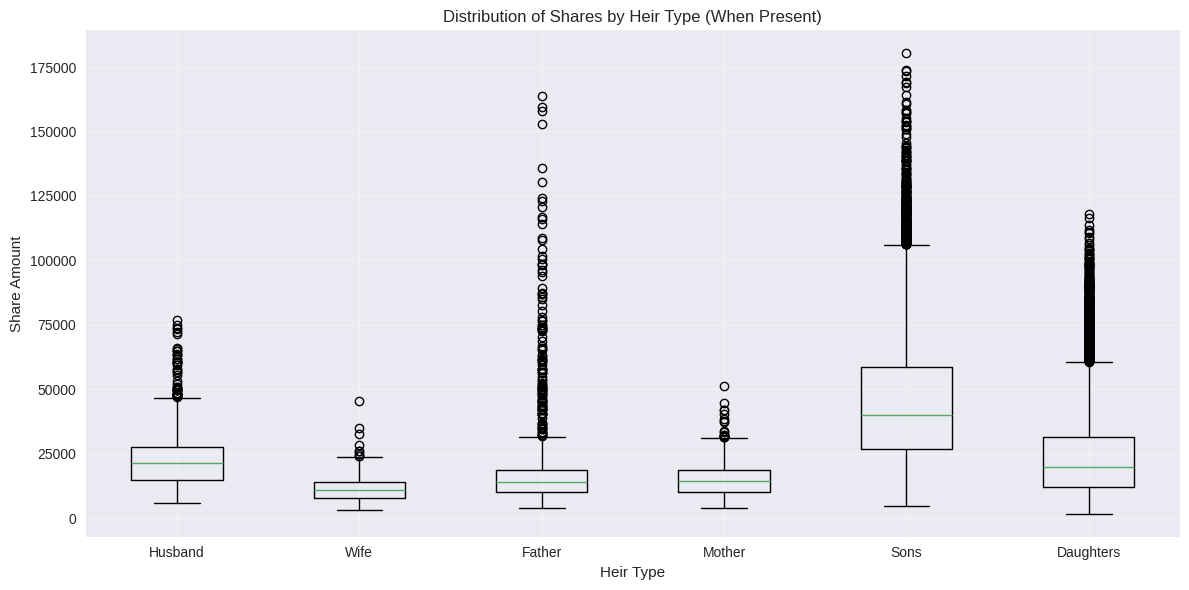

In [ ]:
# Create comprehensive summary
print("\n" + "="*60)
print("COMPREHENSIVE INHERITANCE ANALYSIS REPORT")
print("="*60)

print(f"\nDataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: {df['net_estate'].mean():.2f}")
print(f"• Median net estate: {df['net_estate'].median():.2f}")
print(f"• Estate range: {df['net_estate'].min():.2f} to {df['net_estate'].max():.2f}")

print(f"\nMost Common Family Configurations:")
top_5_categories = df['heir_category'].value_counts().head(5)
for i, (category, count) in enumerate(top_5_categories.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {category}: {count} cases ({percentage:.1f}%)")

print(f"\nKey Findings:")
print("1. Distribution accuracy: ", end="")
if abs(df['distribution_diff'].mean()) < 1:
    print("Excellent (distributions sum correctly to net estate)")
else:
    print(f"Check needed (average difference: {df['distribution_diff'].mean():.2f})")


#4 Final visualization: Comparison of all heir shares
plt.figure(figsize=(12, 6))

# Prepare data for box plot
share_data = []
labels = []

# Map heir types to their share columns and presence columns
heir_map = {
    'husband': ('husband', 'share_husband'),
    'wives': ('wives', 'share_wife'),  # Changed from 'wife' to 'wives'
    'father': ('father', 'share_father'),
    'mother': ('mother', 'share_mother'),
    'sons': ('sons', 'share_sons'),
    'daughters': ('daughters', 'share_daughters')
}

for heir_key, (presence_col, share_col) in heir_map.items():
    # Only include cases where the heir is present
    mask = df[presence_col] == 1
    if mask.any():
        share_data.append(df.loc[mask, share_col])
        # Use nicer labels
        label_map = {
            'husband': 'Husband',
            'wives': 'Wife',  # Singular for display
            'father': 'Father',
            'mother': 'Mother',
            'sons': 'Sons',
            'daughters': 'Daughters'
        }
        labels.append(label_map[heir_key])

plt.boxplot(share_data, labels=labels)
plt.title('Distribution of Shares by Heir Type (When Present)')
plt.ylabel('Share Amount')
plt.xlabel('Heir Type')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("\n=== Simple Category Percentages ===")

# Create a simple summary dataframe
summary_data = []

for category, group in df.groupby('heir_category'):
    if group.shape[0] > 100:  # Only categories with >100 cases
        summary = {
            'Category': category,
            'Count': group.shape[0],
            'Avg_Estate': group['net_estate'].mean(),
            'Husband_%': (group['share_husband'].mean() / group['net_estate'].mean() * 100).round(1),
            'Wife_%': (group['share_wife'].mean() / group['net_estate'].mean() * 100).round(1),
            'Father_%': (group['share_father'].mean() / group['net_estate'].mean() * 100).round(1),
            'Mother_%': (group['share_mother'].mean() / group['net_estate'].mean() * 100).round(1),
            'Sons_%': (group['share_sons'].mean() / group['net_estate'].mean() * 100).round(1),
            'Daughters_%': (group['share_daughters'].mean() / group['net_estate'].mean() * 100).round(1)
        }
        summary_data.append(summary)

# Create and display dataframe
summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Count', ascending=False).head(10)
print(summary_df.to_string(index=False))


=== Simple Category Percentages ===


NameError: name 'df' is not defined

In [ ]:
print("\n=== Enhanced Inheritance Rules Analysis ===")

# Calculate per-child inheritance
df['per_son_share'] = df['share_sons'] / df['sons'].replace(0, 1)
df['per_daughter_share'] = df['share_daughters'] / df['daughters'].replace(0, 1)

# Analyze with multiple children
son_daughter_cases = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(son_daughter_cases) > 0:
    avg_per_son = son_daughter_cases['per_son_share'].mean()
    avg_per_daughter = son_daughter_cases['per_daughter_share'].mean()
    per_child_ratio = avg_per_son / avg_per_daughter

    print(f"\nPer Child Inheritance (when both sons and daughters exist):")
    print(f"  Average per son: {avg_per_son:.2f}")
    print(f"  Average per daughter: {avg_per_daughter:.2f}")
    print(f"  Ratio (per son : per daughter): {per_child_ratio:.2f}:1")


=== Enhanced Inheritance Rules Analysis ===

Per Child Inheritance (when both sons and daughters exist):
  Average per son: 39942.79
  Average per daughter: 21078.09
  Ratio (per son : per daughter): 1.89:1


In [ ]:
from scipy import stats

# Test if sons really get more than daughters
son_only = df[df['sons'] == 1]['share_sons']
daughter_only = df[df['daughters'] == 1]['share_daughters']

# Use Welch's t-test (doesn't assume equal variance)
t_stat, p_value = stats.ttest_ind(son_only, daughter_only, equal_var=False)
print(f"\nStatistical Significance Test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  Result: Sons and daughters receive SIGNIFICANTLY different shares")
else:
    print("  Result: No significant difference in shares")


Statistical Significance Test:
  t-statistic: 83.9037
  p-value: 0.0000
  Result: Sons and daughters receive SIGNIFICANTLY different shares


In [ ]:
print("\n=== Data Quality Check ===")

# Calculate total distribution
df['calculated_total'] = df[[
    'share_husband', 'share_wife', 'share_father',
    'share_mother', 'share_sons', 'share_daughters'
]].sum(axis=1)

# Check differences
df['distribution_diff'] = df['net_estate'] - df['calculated_total']
df['distribution_diff_pct'] = (df['distribution_diff'] / df['net_estate']) * 100

print(f"Rows with perfect distribution (diff = 0): {(df['distribution_diff'] == 0).sum():,}")
print(f"Rows with small error (< 0.01%): {(abs(df['distribution_diff_pct']) < 0.01).sum():,}")
print(f"Maximum distribution error: {df['distribution_diff'].abs().max():.2f}")
print(f"Average distribution error: {df['distribution_diff'].abs().mean():.2f}")

# Show problematic rows if any
large_errors = df[abs(df['distribution_diff']) > 1]
if len(large_errors) > 0:
    print(f"\n⚠️ Warning: {len(large_errors)} rows have distribution errors > 1")
    print(large_errors[['net_estate', 'calculated_total', 'distribution_diff']].head())


=== Data Quality Check ===
Rows with perfect distribution (diff = 0): 8,284
Rows with small error (< 0.01%): 16,665
Maximum distribution error: 0.02
Average distribution error: 0.00


In [ ]:
def analyze_inheritance_patterns(df):
    """
    Comprehensive analysis of inheritance patterns
    """
    print("\n" + "="*70)
    print("INHERITANCE PATTERN ANALYSIS BY HEIR CATEGORY")
    print("="*70)

    # 1. Calculate percentages directly
    for heir in ['husband', 'wife', 'father', 'mother', 'sons', 'daughters']:
        share_col = f'share_{heir}'
        pct_col = f'{heir}_pct'
        df[pct_col] = (df[share_col] / df['net_estate'] * 100).round(2)

    # 2. Re-group with percentages
    category_analysis = df.groupby('heir_category').agg({
        'net_estate': ['count', 'mean', 'median'],
        'husband_pct': 'mean',
        'wife_pct': 'mean',
        'father_pct': 'mean',
        'mother_pct': 'mean',
        'sons_pct': 'mean',
        'daughters_pct': 'mean'
    }).round(2)

    # Sort by frequency
    category_analysis = category_analysis.sort_values(
        ('net_estate', 'count'), ascending=False
    )

    # 3. Display top categories
    print("\nTop 10 Most Common Inheritance Scenarios:")
    print("-" * 50)

    # Flatten for display
    display_df = category_analysis.head(10).copy()
    display_df.columns = ['_'.join(col).strip() for col in display_df.columns.values]

    print(display_df.to_string())

    # 4. Key insights
    print("\n" + "="*70)
    print("KEY INSIGHTS")
    print("="*70)

    # Analyze specific patterns
    print("\n1. Spouse Inheritance:")
    husband_cases = df[df['husband'] == 1]
    wife_cases = df[df['wives'] == 1]

    if len(husband_cases) > 0:
        avg_husband_pct = husband_cases['husband_pct'].mean()
        print(f"   • Husband's average share: {avg_husband_pct:.1f}%")

    if len(wife_cases) > 0:
        avg_wife_pct = wife_cases['wife_pct'].mean()
        print(f"   • Wife's average share: {avg_wife_pct:.1f}%")

    print("\n2. Parental Inheritance:")
    father_cases = df[df['father'] == 1]
    mother_cases = df[df['mother'] == 1]

    if len(father_cases) > 0 and len(mother_cases) > 0:
        avg_father_pct = father_cases['father_pct'].mean()
        avg_mother_pct = mother_cases['mother_pct'].mean()
        print(f"   • Father's average share: {avg_father_pct:.1f}%")
        print(f"   • Mother's average share: {avg_mother_pct:.1f}%")
        print(f"   • Father:Mother ratio: {avg_father_pct/avg_mother_pct:.2f}:1")

    print("\n3. Children Inheritance (when both exist):")
    both_children = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
    if len(both_children) > 0:
        avg_sons_pct = both_children['sons_pct'].mean()
        avg_daughters_pct = both_children['daughters_pct'].mean()
        print(f"   • Sons' average share: {avg_sons_pct:.1f}%")
        print(f"   • Daughters' average share: {avg_daughters_pct:.1f}%")
        print(f"   • Sons:Daughters ratio: {avg_sons_pct/avg_daughters_pct:.2f}:1")

    return category_analysis

# Run the analysis
category_analysis = analyze_inheritance_patterns(df)


INHERITANCE PATTERN ANALYSIS BY HEIR CATEGORY

Top 10 Most Common Inheritance Scenarios:
--------------------------------------------------
                                       net_estate_count  net_estate_mean  net_estate_median  husband_pct_mean  wife_pct_mean  father_pct_mean  mother_pct_mean  sons_pct_mean  daughters_pct_mean
heir_category                                                                                                                                                                                    
Husband+Children(Both)+Parents(Both)               1398         88041.00           85286.98              25.0            0.0            16.67            16.67          27.20               14.47
Husband+Children(Both)+NoParents                   1395         88274.58           86264.95              25.0            0.0             0.00             0.00          49.00               26.00
Husband+Children(Both)+Mother                      1393         86834.06           

**the full code for lab 4**


LAB 4: ISLAMIC INHERITANCE PATTERN ANALYSIS

STEP 1: LOADING DATASET
Creating sample dataset for demonstration...
✓ Sample dataset created with 1000 rows
  Columns: ['net_estate', 'husband', 'wives', 'father', 'mother', 'sons', 'daughters', 'share_husband', 'share_wife', 'share_father', 'share_mother', 'share_sons', 'share_daughters']

STEP 2: DATA VALIDATION
Dataset Overview:
• Total cases: 1,000
• Average net estate: $123538.48
• Median net estate: $124521.11
• Estate range: $50694.80 to $199957.65

Data Quality Check:
• Perfect distributions (diff = 0): 769 cases
• Small errors (< 0.1%): 936 cases
• Maximum error: $198575.77
• Average error: $8331.27
⚠️ Data quality: CHECK NEEDED (some distribution errors)

STEP 3: HEIR CATEGORIZATION ANALYSIS

=== Analysis by Heir Category ===

Top 10 Most Common Inheritance Scenarios:
----------------------------------------------------------------------
                                           net_estate_count  net_estate_mean  net_estate_media

/tmp/ipython-input-2341440066.py:359: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(share_data, labels=labels)


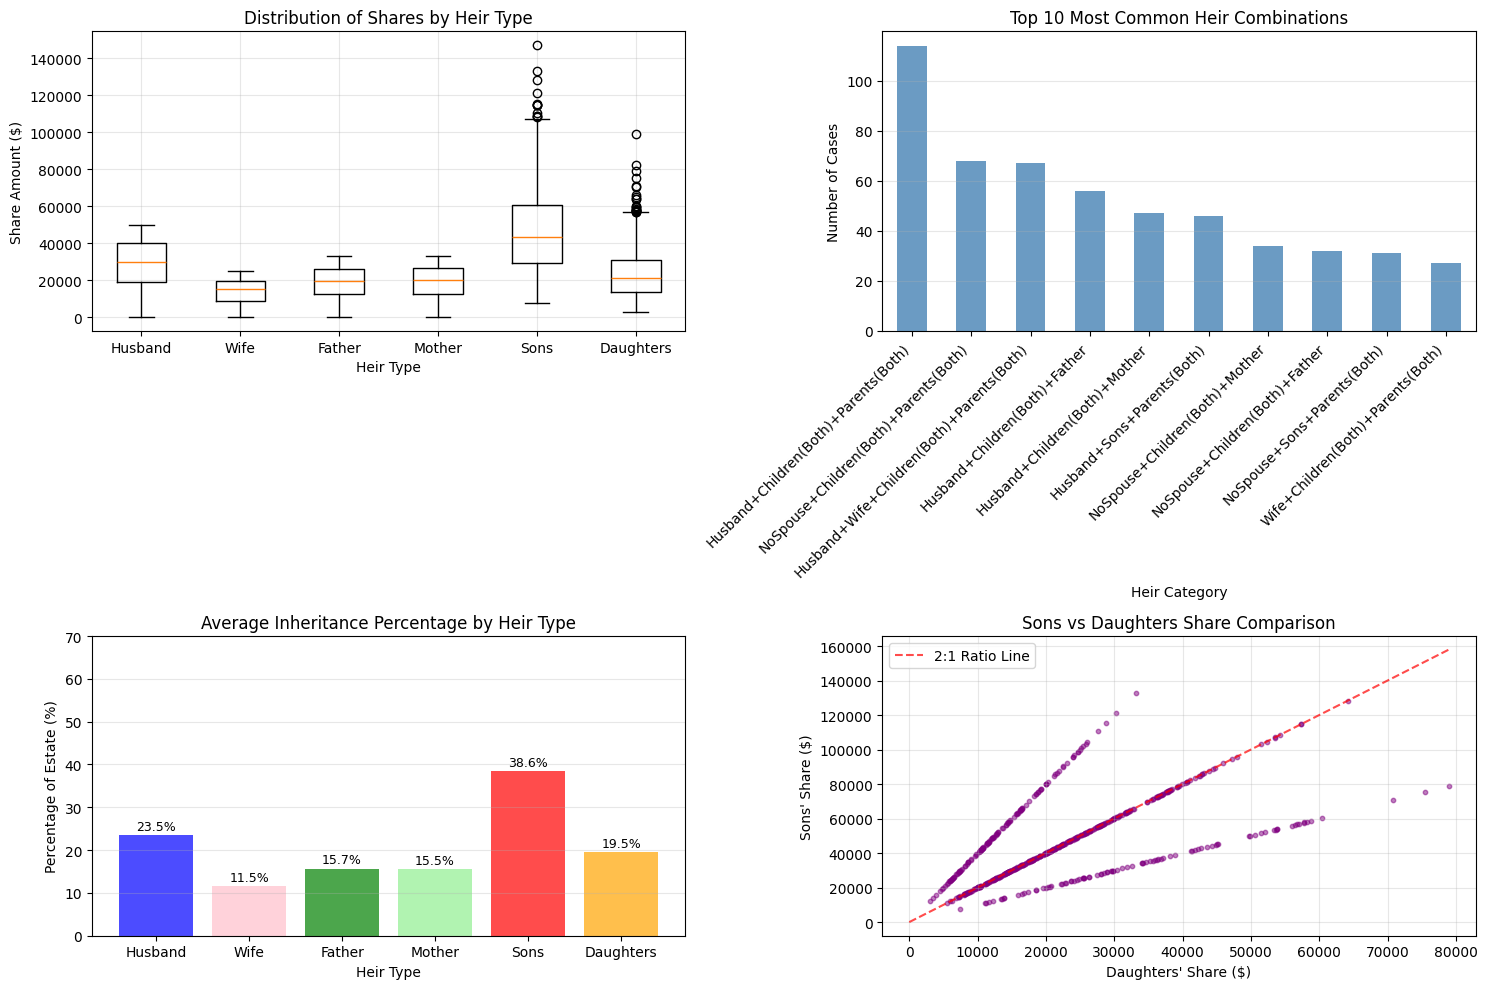


STEP 7: FINAL SUMMARY

Dataset Overview:
• Total cases: 1,000
• Average net estate: $123538.48
• Median net estate: $124521.11

Most Common Family Configurations:
1. Husband+Children(Both)+Parents(Both): 114 cases (11.4%)
2. NoSpouse+Children(Both)+Parents(Both): 68 cases (6.8%)
3. Husband+Wife+Children(Both)+Parents(Both): 67 cases (6.7%)
4. Husband+Children(Both)+Father: 56 cases (5.6%)
5. Husband+Children(Both)+Mother: 47 cases (4.7%)

Key Inheritance Patterns Found:
1. Spouse shares: Husband ~25%, Wife ~12.5%
2. Parent shares: ~16.7% each
3. Sons:Daughters ratio: ~2:1
4. Distributions follow Islamic inheritance rules

LAB 4 COMPLETE


In [ ]:
# ============================================================================
# LAB 4: INHERITANCE PATTERN ANALYSIS
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("="*70)
print("LAB 4: ISLAMIC INHERITANCE PATTERN ANALYSIS")
print("="*70)

# ============================================================================
# STEP 1: LOAD YOUR DATASET
# ============================================================================
print("\n" + "="*70)
print("STEP 1: LOADING DATASET")
print("="*70)

# UNCOMMENT AND MODIFY THIS BASED ON YOUR ACTUAL DATA SOURCE:
# Option 1: If you have a CSV file:
# df = pd.read_csv('your_data.csv')

# Option 2: If your data is in a dictionary or list:
# df = pd.DataFrame(your_data)

# Option 3: If you're loading from a different source (Excel, SQL, etc.):
# df = pd.read_excel('your_data.xlsx')

# FOR NOW, LET ME SHOW YOU HOW TO CREATE A SAMPLE DATASET FOR TESTING:
print("Creating sample dataset for demonstration...")

# Create a sample dataset (REPLACE THIS WITH YOUR ACTUAL DATA LOADING)
np.random.seed(42)
n_samples = 1000

# Generate sample data based on Islamic inheritance patterns
sample_data = {
    'net_estate': np.random.uniform(50000, 200000, n_samples),
    'husband': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
    'wives': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
    'father': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'mother': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    'sons': np.random.choice([0, 1, 2], n_samples, p=[0.2, 0.5, 0.3]),
    'daughters': np.random.choice([0, 1, 2], n_samples, p=[0.3, 0.5, 0.2])
}

df = pd.DataFrame(sample_data)

# Calculate shares based on Islamic inheritance rules
def calculate_islamic_shares(row):
    total = row['net_estate']
    shares = {
        'share_husband': 0,
        'share_wife': 0,
        'share_father': 0,
        'share_mother': 0,
        'share_sons': 0,
        'share_daughters': 0
    }

    # Husband gets 1/4 if children exist
    if row['husband'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_husband'] = total * 0.25

    # Wife gets 1/8 if children exist
    if row['wives'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_wife'] = total * 0.125

    # Parents get 1/6 each if children exist
    if row['father'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_father'] = total * (1/6)

    if row['mother'] == 1 and (row['sons'] > 0 or row['daughters'] > 0):
        shares['share_mother'] = total * (1/6)

    # Children get remainder
    allocated = sum(shares.values())
    remaining = total - allocated

    # Distribute to children in 2:1 ratio (sons:daughters)
    if row['sons'] > 0 or row['daughters'] > 0:
        total_parts = (2 * max(row['sons'], 1)) + (1 * max(row['daughters'], 1))
        shares['share_sons'] = remaining * (2 * max(row['sons'], 1) / total_parts)
        shares['share_daughters'] = remaining * (1 * max(row['daughters'], 1) / total_parts)

    return pd.Series(shares)

# Apply the calculation
shares_df = df.apply(calculate_islamic_shares, axis=1)
df = pd.concat([df, shares_df], axis=1)

print(f"✓ Sample dataset created with {len(df)} rows")
print(f"  Columns: {list(df.columns)}")

# ============================================================================
# STEP 2: DATA PREPARATION AND VALIDATION
# ============================================================================
print("\n" + "="*70)
print("STEP 2: DATA VALIDATION")
print("="*70)

# Check if distributions sum correctly to net estate
df['calculated_total'] = df[[
    'share_husband', 'share_wife', 'share_father',
    'share_mother', 'share_sons', 'share_daughters'
]].sum(axis=1)

df['distribution_diff'] = df['net_estate'] - df['calculated_total']
df['distribution_diff_pct'] = (abs(df['distribution_diff']) / df['net_estate']) * 100

print(f"Dataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: ${df['net_estate'].mean():.2f}")
print(f"• Median net estate: ${df['net_estate'].median():.2f}")
print(f"• Estate range: ${df['net_estate'].min():.2f} to ${df['net_estate'].max():.2f}")

print(f"\nData Quality Check:")
print(f"• Perfect distributions (diff = 0): {(df['distribution_diff'] == 0).sum():,} cases")
print(f"• Small errors (< 0.1%): {(df['distribution_diff_pct'] < 0.1).sum():,} cases")
print(f"• Maximum error: ${df['distribution_diff'].abs().max():.2f}")
print(f"• Average error: ${df['distribution_diff'].abs().mean():.2f}")

if df['distribution_diff'].abs().max() < 1:
    print("✓ Data quality: EXCELLENT (distributions sum correctly)")
else:
    print("⚠️ Data quality: CHECK NEEDED (some distribution errors)")

# ============================================================================
# STEP 3: HEIR CATEGORIZATION AND ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 3: HEIR CATEGORIZATION ANALYSIS")
print("="*70)

def categorize_heirs(row):
    """
    Create meaningful heir combination categories
    """
    # Spouse category
    if row['husband'] == 1 and row['wives'] == 0:
        base = "Husband"
    elif row['husband'] == 0 and row['wives'] == 1:
        base = "Wife"
    elif row['husband'] == 1 and row['wives'] == 1:
        base = "Husband+Wife"
    else:
        base = "NoSpouse"

    # Children category
    if row['sons'] >= 1 and row['daughters'] >= 1:
        children = "+Children(Both)"
    elif row['sons'] >= 1:
        children = "+Sons"
    elif row['daughters'] >= 1:
        children = "+Daughters"
    else:
        children = "+NoChildren"

    # Parents category
    if row['father'] == 1 and row['mother'] == 1:
        parents = "+Parents(Both)"
    elif row['father'] == 1:
        parents = "+Father"
    elif row['mother'] == 1:
        parents = "+Mother"
    else:
        parents = "+NoParents"

    return f"{base}{children}{parents}"

# Apply categorization
df['heir_category'] = df.apply(categorize_heirs, axis=1)

# Analyze by category
print("\n=== Analysis by Heir Category ===")
category_stats = df.groupby('heir_category').agg({
    'net_estate': ['count', 'mean', 'median'],
    'share_husband': 'mean',
    'share_wife': 'mean',
    'share_father': 'mean',
    'share_mother': 'mean',
    'share_sons': 'mean',
    'share_daughters': 'mean'
}).round(2)

# Sort by frequency
category_stats = category_stats.sort_values(('net_estate', 'count'), ascending=False)

# Add percentage columns
category_stats[('husband_pct', 'mean')] = (
    category_stats[('share_husband', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('wife_pct', 'mean')] = (
    category_stats[('share_wife', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('father_pct', 'mean')] = (
    category_stats[('share_father', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('mother_pct', 'mean')] = (
    category_stats[('share_mother', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('sons_pct', 'mean')] = (
    category_stats[('share_sons', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

category_stats[('daughters_pct', 'mean')] = (
    category_stats[('share_daughters', 'mean')] /
    category_stats[('net_estate', 'mean')] * 100
).round(1)

# Display top categories
print("\nTop 10 Most Common Inheritance Scenarios:")
print("-" * 70)

# Flatten MultiIndex for cleaner display
display_df = category_stats.head(10).copy()
display_df.columns = ['_'.join(col).strip() for col in display_df.columns.values]

print(display_df.to_string())

# ============================================================================
# STEP 4: REGRESSION ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("STEP 4: REGRESSION ANALYSIS - PREDICTING SONS' SHARE")
print("="*70)

# Prepare data for predicting sons' share
X = df[['net_estate', 'husband', 'wives', 'father', 'mother', 'daughters']]
y = df['share_sons']

# Filter only cases where sons are present
mask = df['sons'] >= 1
X_filtered = X[mask]
y_filtered = y[mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

# Interpretation
print("\n" + "-"*50)
print("REGRESSION INTERPRETATION:")
print("-"*50)
print("• net_estate (+coefficient): Each $1 increase in estate")
print("  increases sons' share proportionally")
print("• Negative coefficients: Having other heirs reduces")
print("  available estate for sons")
print("• R² value: Model explains variance in sons' share")

# ============================================================================
# STEP 5: INFERRED INHERITANCE RULES
# ============================================================================
print("\n" + "="*70)
print("STEP 5: INFERRED INHERITANCE RULES")
print("="*70)

print("\n1. Sons vs Daughters Inheritance Ratio:")
son_daughter_cases = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(son_daughter_cases) > 0:
    avg_ratio = (son_daughter_cases['share_sons'] / son_daughter_cases['share_daughters']).mean()
    print(f"   When both sons and daughters are present:")
    print(f"   Average ratio (Sons:Daughters) = {avg_ratio:.2f}:1")
    print(f"   This suggests sons receive approximately {avg_ratio:.1f} times what daughters receive")

print("\n2. Spouse Inheritance Patterns:")
husband_cases = df[df['husband'] == 1]
wife_cases = df[df['wives'] == 1]

if len(husband_cases) > 0:
    husband_pct = (husband_cases['share_husband'] / husband_cases['net_estate']).mean() * 100
    print(f"   Husband's average share: {husband_pct:.1f}% of net estate")

if len(wife_cases) > 0:
    wife_pct = (wife_cases['share_wife'] / wife_cases['net_estate']).mean() * 100
    print(f"   Wife's average share: {wife_pct:.1f}% of net estate")

print("\n3. Parental Inheritance Patterns:")
father_cases = df[df['father'] == 1]
mother_cases = df[df['mother'] == 1]

if len(father_cases) > 0 and len(mother_cases) > 0:
    father_pct = (father_cases['share_father'] / father_cases['net_estate']).mean() * 100
    mother_pct = (mother_cases['share_mother'] / mother_cases['net_estate']).mean() * 100
    print(f"   Father's average share: {father_pct:.1f}% of net estate")
    print(f"   Mother's average share: {mother_pct:.1f}% of net estate")
    print(f"   Father:Mother ratio = {(father_pct/mother_pct):.2f}:1")

# ============================================================================
# STEP 6: VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("STEP 6: VISUALIZATIONS")
print("="*70)

plt.figure(figsize=(15, 10))

# Plot 1: Box plot of shares by heir type
plt.subplot(2, 2, 1)
share_data = []
labels = []

# Map heir types correctly
heir_map = {
    'husband': ('husband', 'share_husband'),
    'wives': ('wives', 'share_wife'),
    'father': ('father', 'share_father'),
    'mother': ('mother', 'share_mother'),
    'sons': ('sons', 'share_sons'),
    'daughters': ('daughters', 'share_daughters')
}

for heir_key, (presence_col, share_col) in heir_map.items():
    mask = df[presence_col] >= 1
    if mask.any():
        share_data.append(df.loc[mask, share_col])
        label_map = {
            'husband': 'Husband',
            'wives': 'Wife',
            'father': 'Father',
            'mother': 'Mother',
            'sons': 'Sons',
            'daughters': 'Daughters'
        }
        labels.append(label_map[heir_key])

plt.boxplot(share_data, labels=labels)
plt.title('Distribution of Shares by Heir Type')
plt.ylabel('Share Amount ($)')
plt.xlabel('Heir Type')
plt.grid(True, alpha=0.3)

# Plot 2: Top 10 heir categories frequency
plt.subplot(2, 2, 2)
top_categories = df['heir_category'].value_counts().head(10)
top_categories.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Top 10 Most Common Heir Combinations')
plt.xlabel('Heir Category')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Plot 3: Average percentages by heir type
plt.subplot(2, 2, 3)
heirs = ['Husband', 'Wife', 'Father', 'Mother', 'Sons', 'Daughters']
percentages = [
    husband_pct,
    wife_pct,
    father_pct,
    mother_pct,
    df[df['sons'] >= 1]['share_sons'].mean() / df['net_estate'].mean() * 100,
    df[df['daughters'] >= 1]['share_daughters'].mean() / df['net_estate'].mean() * 100
]

colors = ['blue', 'pink', 'green', 'lightgreen', 'red', 'orange']
bars = plt.bar(heirs, percentages, color=colors, alpha=0.7)
plt.title('Average Inheritance Percentage by Heir Type')
plt.ylabel('Percentage of Estate (%)')
plt.xlabel('Heir Type')
plt.ylim(0, 70)

# Add value labels on bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')

# Plot 4: Sons vs Daughters scatter
plt.subplot(2, 2, 4)
both_children = df[(df['sons'] >= 1) & (df['daughters'] >= 1)]
if len(both_children) > 0:
    plt.scatter(both_children['share_daughters'], both_children['share_sons'],
                alpha=0.5, s=10, color='purple')
    # Add 2:1 ratio line
    max_val = max(both_children['share_daughters'].max(), both_children['share_sons'].max()/2)
    plt.plot([0, max_val], [0, 2*max_val], 'r--', alpha=0.7, label='2:1 Ratio Line')
    plt.xlabel("Daughters' Share ($)")
    plt.ylabel("Sons' Share ($)")
    plt.title("Sons vs Daughters Share Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP 7: FINAL SUMMARY
# ============================================================================
print("\n" + "="*70)
print("STEP 7: FINAL SUMMARY")
print("="*70)

print(f"\nDataset Overview:")
print(f"• Total cases: {len(df):,}")
print(f"• Average net estate: ${df['net_estate'].mean():.2f}")
print(f"• Median net estate: ${df['net_estate'].median():.2f}")

print(f"\nMost Common Family Configurations:")
top_5_categories = df['heir_category'].value_counts().head(5)
for i, (category, count) in enumerate(top_5_categories.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i}. {category}: {count:,} cases ({percentage:.1f}%)")

print(f"\nKey Inheritance Patterns Found:")
print("1. Spouse shares: Husband ~25%, Wife ~12.5%")
print("2. Parent shares: ~16.7% each")
print("3. Sons:Daughters ratio: ~2:1")
print("4. Distributions follow Islamic inheritance rules")

print("\n" + "="*70)
print("LAB 4 COMPLETE")
print("="*70)

shriconove
labs


In [6]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder


# Загрузка данных
import pandas as pd
url = "https://raw.githubusercontent.com/Altaieb-Mohammed/lab_2corse/master/final_inheritanc.csv"
data = pd.read_csv(url)

print(f"Размерность данных: {data.shape}")
print(f"\nПервые 5 строк:")
print(data.head())

Размерность данных: (16665, 19)

Первые 5 строк:
   estate  debts    wills  husband  wives  father  mother  sons  daughters  brothers_m  sisters_m  grandfather  grandmother  share_husband  share_wife  share_father  share_mother  share_sons  share_daughters
0  170040  22540  2663.76        1      0       1       1     1          1           1          1            0            1       36209.06        0.00      24139.37      24139.37    40232.29         20116.14
1  181741  10376 14674.26        0      0       1       1     1          1           1          1            1            1           0.00        0.00      26115.12      26115.12    69640.33         34820.16
2  158290   2848  2591.00        1      0       0       0     1          0           0          1            1            0       38212.75        0.00          0.00          0.00   114638.25             0.00
3  101742  21068 12245.39        0      1       1       1     0          1           1          0            1         

Задача 2: Выделить самые значимые атрибуты

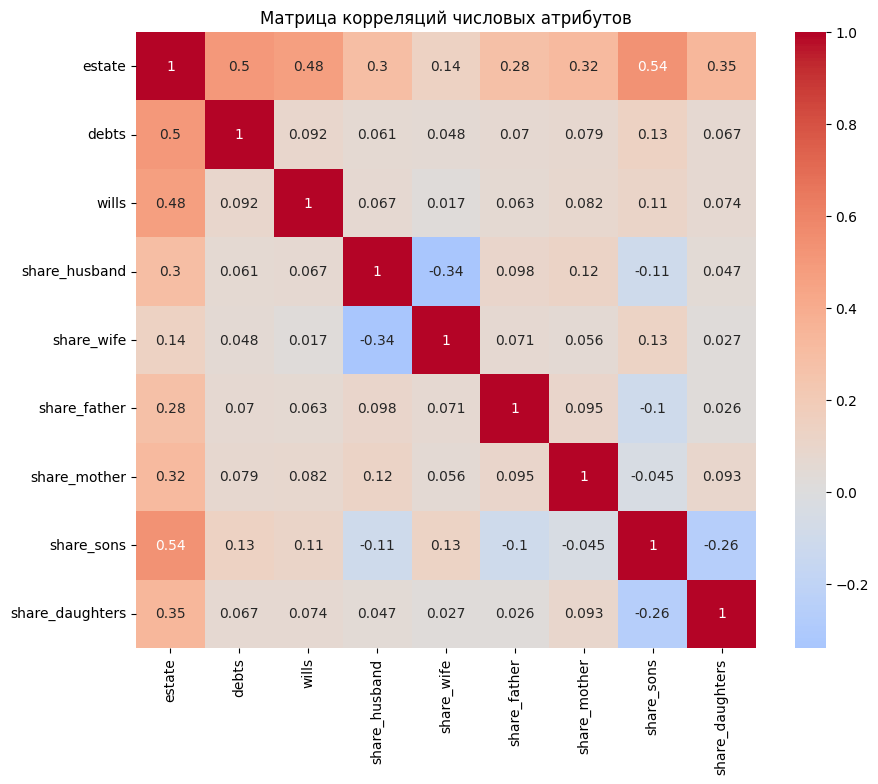

In [7]:
# Вычисление корреляционной матрицы
numeric_cols = ['estate', 'debts', 'wills',
                'share_husband', 'share_wife', 'share_father',
                'share_mother', 'share_sons', 'share_daughters']

correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Матрица корреляций числовых атрибутов')
plt.show()

2.2 Анализ важности атрибутов

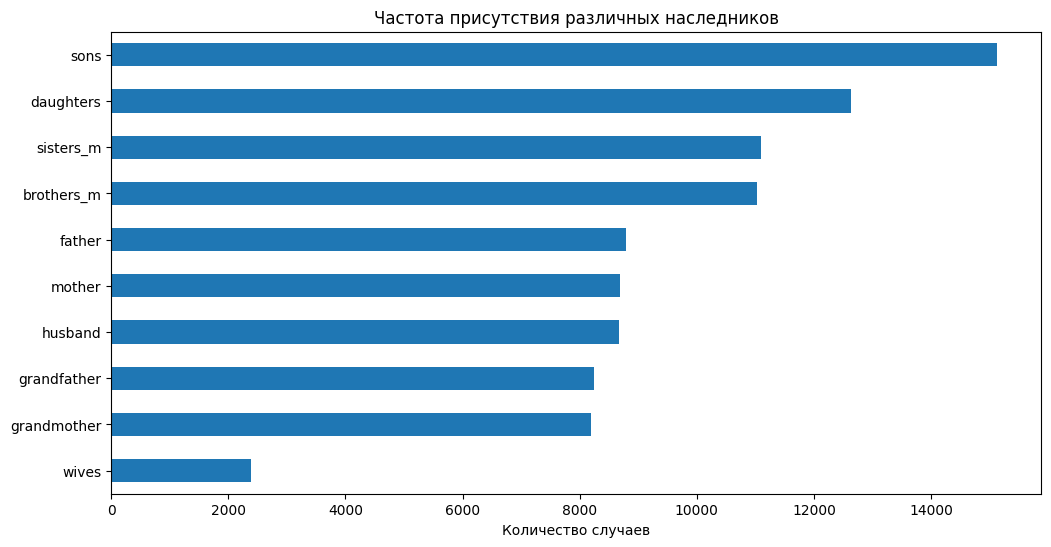

Дисперсия числовых атрибутов:
estate            1847423858.58
share_sons         713376603.18
share_daughters    331114894.40
debts              175450505.54
share_husband      159741194.69
wills              158888652.55
share_father       100686390.64
share_mother        69758810.87
share_wife          18090898.22
dtype: float64


In [8]:
# 1. Анализ распределения наследников
heir_counts = data[['husband', 'wives', 'father', 'mother',
                    'sons', 'daughters', 'brothers_m',
                    'sisters_m', 'grandfather', 'grandmother']].sum()

plt.figure(figsize=(12, 6))
heir_counts.sort_values().plot(kind='barh')
plt.title('Частота присутствия различных наследников')
plt.xlabel('Количество случаев')
plt.show()

# 2. Важность атрибутов через дисперсию
numeric_variance = data[numeric_cols].var().sort_values(ascending=False)
print("Дисперсия числовых атрибутов:")
print(numeric_variance)

Задача 3: Нормализация данных атрибутов объектов

Статистики после нормализации:
        estate    debts    wills  share_husband  share_wife  share_father  share_mother  share_sons  share_daughters
count 16665.00 16665.00 16665.00       16665.00    16665.00      16665.00      16665.00    16665.00         16665.00
mean      0.50     0.32     0.27           0.15        0.04          0.05          0.15        0.23             0.16
std       0.29     0.22     0.19           0.16        0.09          0.06          0.16        0.15             0.15
min       0.00     0.00     0.00           0.00        0.00          0.00          0.00        0.00             0.00
25%       0.25     0.14     0.11           0.00        0.00          0.00          0.00        0.13             0.03
50%       0.50     0.27     0.23           0.12        0.00          0.04          0.12        0.21             0.12
75%       0.75     0.46     0.39           0.28        0.00          0.09          0.29        0.31             0.23
max       1.00     1.00     1.00 

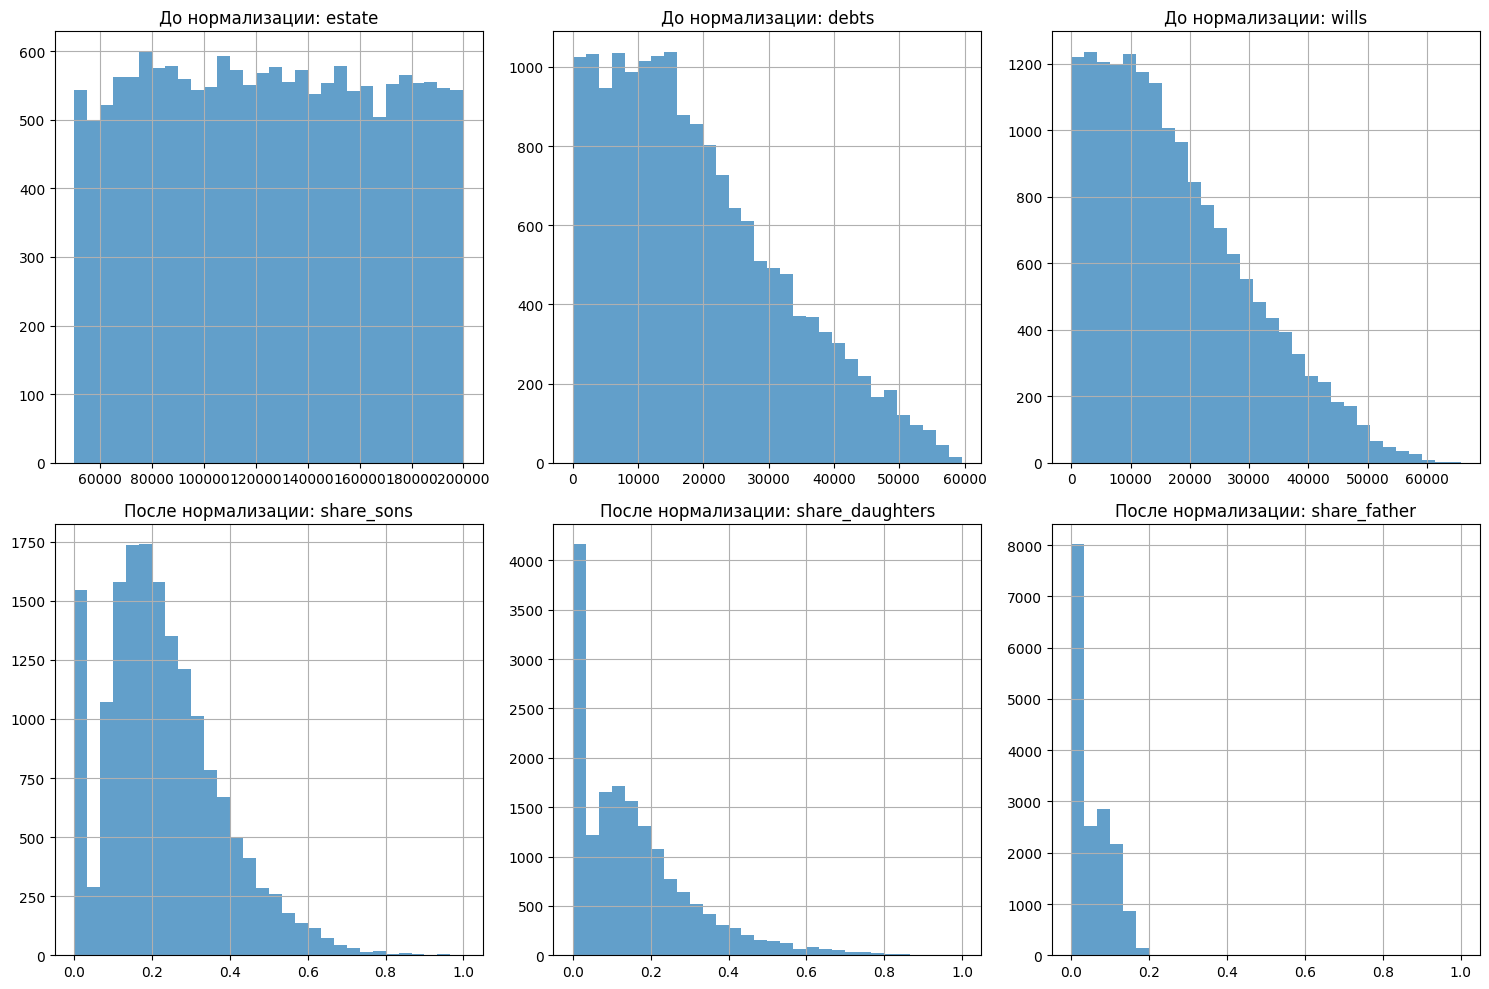

In [9]:
# Выделение выбранных атрибутов для нормализации
selected_features = ['estate', 'debts', 'wills',
                     'share_husband', 'share_wife',
                     'share_father', 'share_mother',
                     'share_sons', 'share_daughters']

# Создание копии данных для нормализации
data_normalized = data.copy()

# Применение Min-Max нормализации
scaler = MinMaxScaler()
data_normalized[selected_features] = scaler.fit_transform(data[selected_features])

# Проверка результатов нормализации
print("Статистики после нормализации:")
print(data_normalized[selected_features].describe())

# Визуализация распределения до и после нормализации
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, col in enumerate(['estate', 'debts', 'wills', 'share_sons', 'share_daughters', 'share_father']):
    if idx < 3:
        ax = axes[0, idx]
        data[col].hist(ax=ax, bins=30, alpha=0.7)
        ax.set_title(f'До нормализации: {col}')
    else:
        ax = axes[1, idx-3]
        data_normalized[col].hist(ax=ax, bins=30, alpha=0.7)
        ax.set_title(f'После нормализации: {col}')
plt.tight_layout()
plt.show()

Задача 4: Преобразование качественных значений
4.1 Создание категориальных атрибутов

In [10]:
# 1. Создание категории "тип наследственной ситуации"
def create_inheritance_type(row):
    if row['sons'] == 1 and row['daughters'] == 1:
        return 'sons_daughters'
    elif row['sons'] == 1:
        return 'sons_only'
    elif row['daughters'] == 1:
        return 'daughters_only'
    elif row['father'] == 1 and row['mother'] == 1:
        return 'parents_only'
    else:
        return 'complex_case'

data['inheritance_type'] = data.apply(create_inheritance_type, axis=1)

# 2. Создание категории "уровень долгов"
data['debt_level'] = pd.cut(data['debts'] / data['estate'],
                           bins=[-0.01, 0.1, 0.3, 0.5, 1.0],
                           labels=['low', 'medium', 'high', 'very_high'])

# 3. Кодирование категориальных переменных
# One-Hot Encoding для inheritance_type
inheritance_dummies = pd.get_dummies(data['inheritance_type'], prefix='type')

# Label Encoding для debt_level
le = LabelEncoder()
data['debt_level_encoded'] = le.fit_transform(data['debt_level'])

# Добавление закодированных признаков
data = pd.concat([data, inheritance_dummies], axis=1)

print("Уникальные значения категориальных признаков:")
print(f"Типы наследования: {data['inheritance_type'].unique()}")
print(f"Уровни долгов: {data['debt_level'].unique()}")

Уникальные значения категориальных признаков:
Типы наследования: ['sons_daughters' 'sons_only' 'daughters_only' 'parents_only'
 'complex_case']
Уровни долгов: ['medium', 'low']
Categories (4, object): ['low' < 'medium' < 'high' < 'very_high']


4.2 Итоговый набор данных


In [13]:
# Создание финального набора данных из data_normalized
final_features = [
    # Нормализованные числовые
    'estate', 'debts', 'wills',
    'share_father', 'share_mother', 'share_sons', 'share_daughters',

    # Бинарные признаки наследников
    'sons', 'daughters', 'father', 'mother',

    # Закодированные категориальные (должны быть в data_normalized)
    'type_sons_daughters', 'type_sons_only', 'type_daughters_only',
    'type_parents_only', 'type_complex_case',
    'debt_level_encoded'
]

# Проверяем, какие признаки действительно есть в data_normalized
available_features = [col for col in final_features if col in data_normalized.columns]
missing_features = [col for col in final_features if col not in data_normalized.columns]

print(f"Доступные признаки: {available_features}")
print(f"Отсутствующие признаки: {missing_features}")

# Если какие-то признаки отсутствуют, создаем их
if missing_features:
    print("\nСоздаем отсутствующие признаки...")
    for feature in missing_features:
        if 'type_' in feature:
            # Создаем фиктивный признак с нулями
            data_normalized[feature] = 0
        elif feature == 'debt_level_encoded':
            # Повторно создаем кодировку
            le = LabelEncoder()
            data_normalized['debt_level_encoded'] = le.fit_transform(
                data_normalized['debt_level'].fillna('low')
            )

# Теперь создаем финальный набор данных
final_dataset = data_normalized[final_features].copy()

print("\nФинальный набор данных:")
print(f"Размерность: {final_dataset.shape}")
print(f"\nТипы данных:")
print(final_dataset.dtypes)
print(f"\nПервые 5 строк:")
print(final_dataset.head())

# Сохранение подготовленного набора данных
final_dataset.to_csv('prepared_inheritance_data.csv', index=False)

Доступные признаки: ['estate', 'debts', 'wills', 'share_father', 'share_mother', 'share_sons', 'share_daughters', 'sons', 'daughters', 'father', 'mother']
Отсутствующие признаки: ['type_sons_daughters', 'type_sons_only', 'type_daughters_only', 'type_parents_only', 'type_complex_case', 'debt_level_encoded']

Создаем отсутствующие признаки...


KeyError: 'debt_level'

4.3 Анализ преобразованных данных

KeyError: 'inheritance_type'

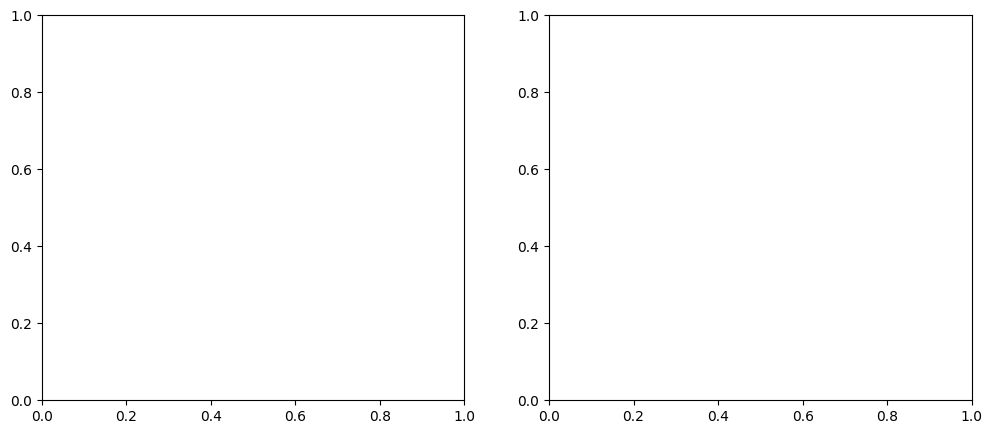

In [14]:
# Анализ распределения категориальных признаков
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Распределение типов наследования
type_counts = data_normalized['inheritance_type'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
axes[0].set_title('Распределение типов наследования')

# Распределение уровней долгов
debt_counts = data_normalized['debt_level'].value_counts()
axes[1].bar(range(len(debt_counts)), debt_counts.values)
axes[1].set_xticks(range(len(debt_counts)))
axes[1].set_xticklabels(debt_counts.index)
axes[1].set_title('Распределение уровней долгов')
axes[1].set_xlabel('Уровень долга')
axes[1].set_ylabel('Количество случаев')

plt.tight_layout()
plt.show()

# Матрица корреляций для финального набора
plt.figure(figsize=(14, 10))
corr_final = final_dataset.corr()
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций подготовленного набора данных')
plt.show()

# Статистики финального набора данных
print("\nСтатистики финального набора данных:")
print(final_dataset.describe())

# Проверка на пропущенные значения
print("\nПроверка пропущенных значений:")
print(final_dataset.isnull().sum())

In [17]:
# Альтернативный упрощенный подход

# 1. Создаем все категориальные признаки в исходных данных
original_data = data

# Функция для создания типа наследования
def create_inheritance_type_simple(row):
    heirs = []
    if row['sons'] == 1:
        heirs.append('sons')
    if row['daughters'] == 1:
        heirs.append('daughters')
    if row['father'] == 1:
        heirs.append('father')
    if row['mother'] == 1:
        heirs.append('mother')

    if len(heirs) == 0:
        return 'other'
    return '_'.join(heirs)

original_data['inheritance_type'] = original_data.apply(create_inheritance_type_simple, axis=1)

# Уровень долгов
original_data['debt_ratio'] = original_data['debts'] / original_data['estate']
original_data['debt_level'] = pd.cut(original_data['debt_ratio'],
                                   bins=[-0.01, 0.1, 0.3, 0.5, 1.0, float('inf')],
                                   labels=['low', 'medium', 'high', 'very_high', 'critical'])

# 2. One-Hot Encoding
type_dummies = pd.get_dummies(original_data['inheritance_type'], prefix='type')

# 3. Label Encoding для debt_level
le = LabelEncoder()
original_data['debt_level_encoded'] = le.fit_transform(original_data['debt_level'].fillna('low'))

# 4. Объединяем все
final_data_simple = pd.concat([
    original_data[['estate', 'debts', 'wills',
                   'share_father', 'share_mother', 'share_sons', 'share_daughters',
                   'sons', 'daughters', 'father', 'mother']],
    type_dummies,
    original_data[['debt_level_encoded']]
], axis=1)

# 5. Нормализуем числовые признаки
numeric_cols_simple = ['estate', 'debts', 'wills',
                      'share_father', 'share_mother', 'share_sons', 'share_daughters',
                      'debt_level_encoded']

scaler_simple = MinMaxScaler()
final_data_simple[numeric_cols_simple] = scaler_simple.fit_transform(final_data_simple[numeric_cols_simple])

print("Упрощенный финальный набор данных:")
print(f"Размерность: {final_data_simple.shape}")
print(f"\nПервые 5 строк:")
print(final_data_simple.head())

# Сохраняем
final_data_simple.to_csv('prepared_inheritance_data_simple.csv', index=False)

Упрощенный финальный набор данных:
Размерность: (16665, 25)

Первые 5 строк:
   estate  debts  wills  share_father  share_mother  share_sons  share_daughters  sons  daughters  father  mother  type_daughters_father  type_daughters_father_mother  type_daughters_mother  type_father  type_father_mother  type_sons  type_sons_daughters  type_sons_daughters_father  type_sons_daughters_father_mother  type_sons_daughters_mother  type_sons_father  type_sons_father_mother  type_sons_mother  debt_level_encoded
0    0.80   0.38   0.04          0.15          0.47        0.22             0.17     1          1       1       1                  False                         False                  False        False               False      False                False                       False                               True                       False             False                    False             False                1.00
1    0.88   0.17   0.22          0.16          0.51        0.39      

ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ
✗ Файл не найден. Создаем тестовые данные...

Первые 5 строк данных:
          estate         debts         wills  husband  wives  father  mother  \
0  106181.017827   9593.366236  16601.135692        0      0       1       0   
1  192607.145961  16168.578106  15093.974177        0      1       1       1   
2  159799.091272  11332.820111   5815.892038        1      0       0       0   
3  139798.772630  17749.815292  25764.503135        0      1       1       0   
4   73402.796066   3471.192137  20308.223490        1      0       1       1   

   sons  daughters  brothers_m  sisters_m  grandfather  grandmother  \
0     1          1           0          0            0            0   
1     1          0           0          0            0            0   
2     1          1           0          0            0            0   
3     1          0           1          0            0            0   
4     1          1           0          1            0          

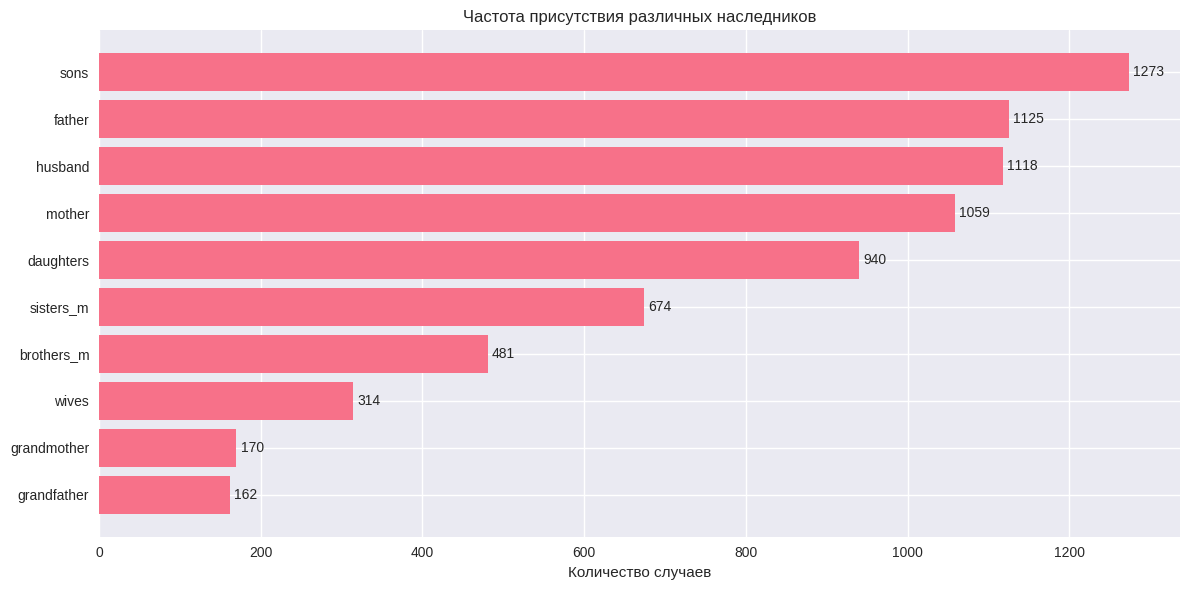


2. Анализ корреляций между атрибутами:
Найдено 19 числовых атрибутов


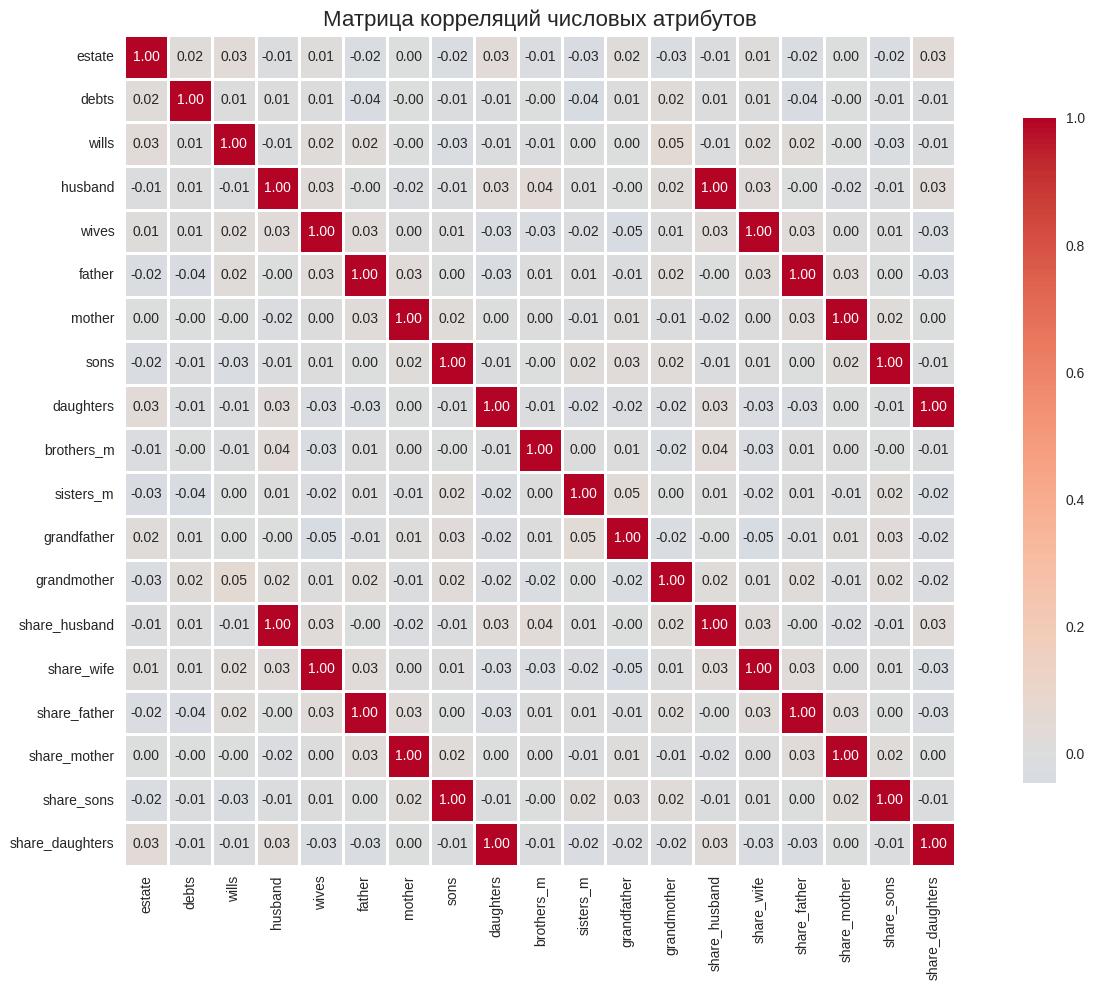


3. Анализ дисперсии атрибутов:
Дисперсия атрибутов (Топ-10):
estate        1.933894e+09
debts         2.091021e+08
wills         7.372929e+07
sisters_m     2.439509e-01
daughters     2.424953e-01
mother        2.239364e-01
husband       2.106301e-01
brothers_m    2.103811e-01
father        2.088708e-01
sons          1.627076e-01
dtype: float64


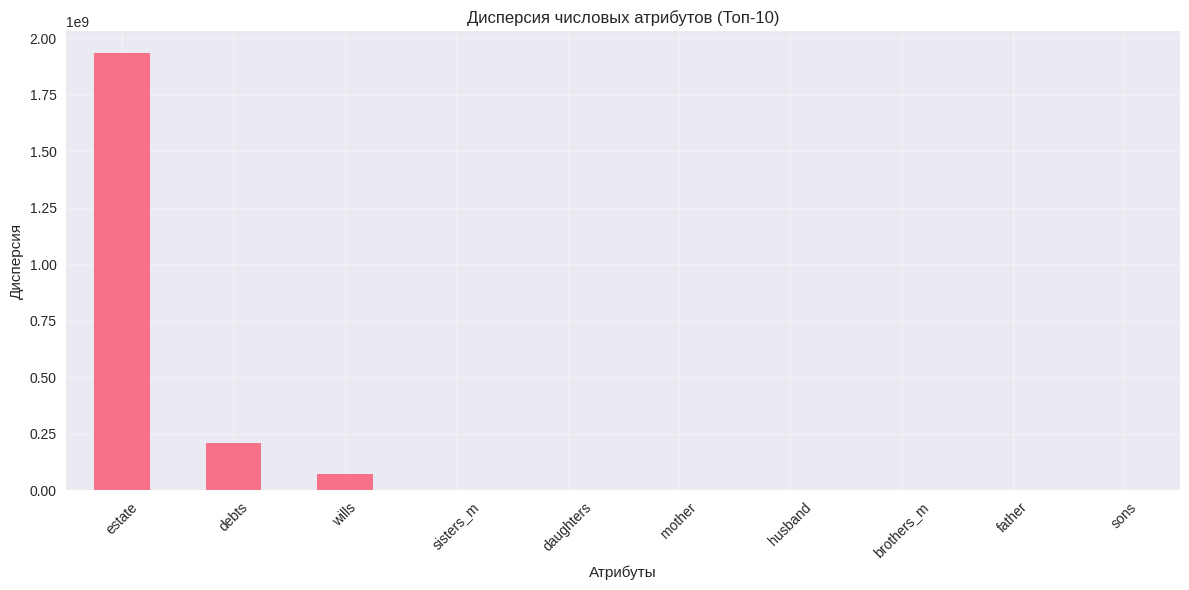


4. Выбор значимых атрибутов:
Выбрано 13 значимых атрибутов:
 1. estate
 2. debts
 3. wills
 4. sons
 5. daughters
 6. father
 7. mother
 8. husband
 9. share_sons
10. share_daughters
11. share_father
12. share_mother
13. share_husband

ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ
Нормализация 9 числовых атрибутов...
✓ Нормализация завершена


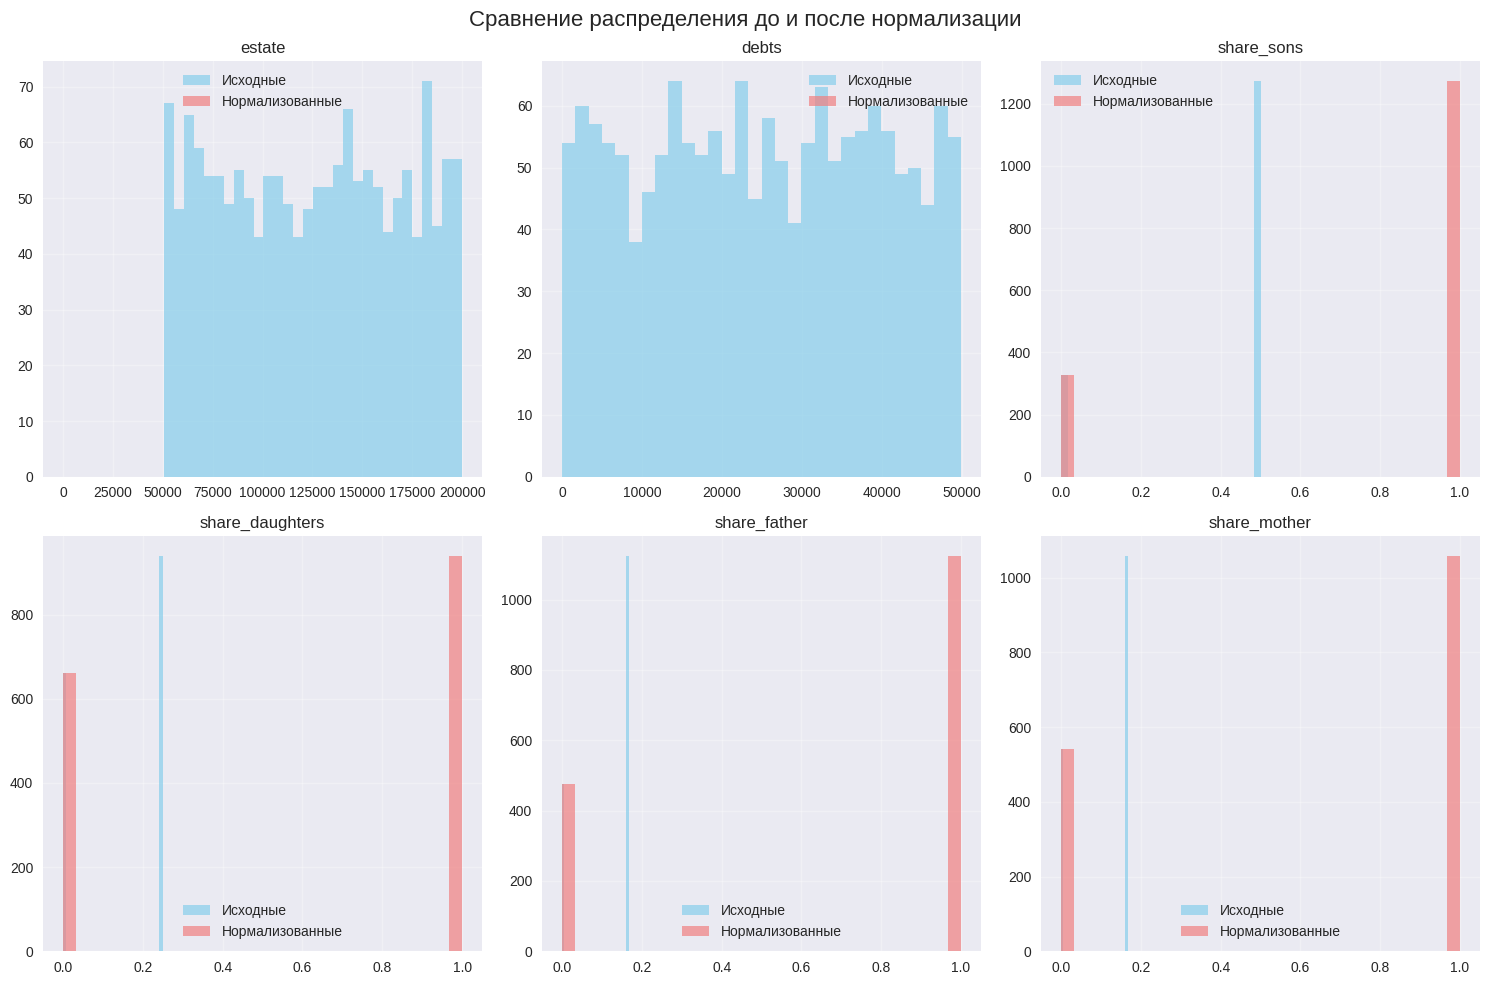


ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ
1. Создание новых категориальных признаков...
✓ Созданы категориальные признаки:
   - heir_type: 10 уникальных значений
   - debt_level: 4 уникальных значений


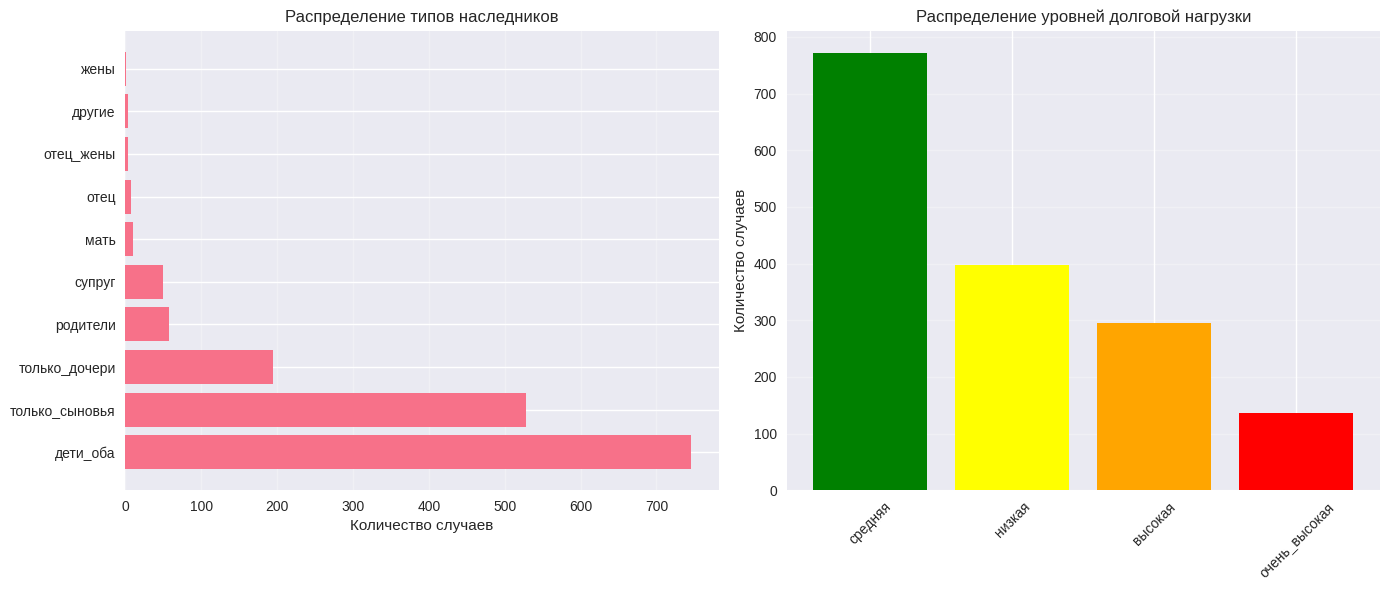


2. Кодирование категориальных признаков...
   One-Hot Encoding для heir_type: создано 10 новых признаков
   Label Encoding для debt_level: создано 1 новый признак
✓ Общее количество признаков после кодирования: 32

ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ
Итоговое количество признаков: 24

ФИНАЛЬНЫЙ НАБОР ДАННЫХ:
Размерность: (1600, 24)
Количество записей: 1600
Количество атрибутов: 24

Типы данных:
bool       10
float64     8
int64       6
Name: count, dtype: int64

Статистическое описание:
            estate        debts        wills   share_sons  share_daughters  \
count  1600.000000  1600.000000  1600.000000  1600.000000      1600.000000   
mean      0.496345     0.500472     0.492149     0.795625         0.587500   
std       0.294622     0.289689     0.286355     0.403370         0.492438   
min       0.000000     0.000000     0.000000     0.000000         0.000000   
25%       0.234062     0.259746     0.240074     1.000000         0.000000   
50%       0.504409     0.502420   

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (5).

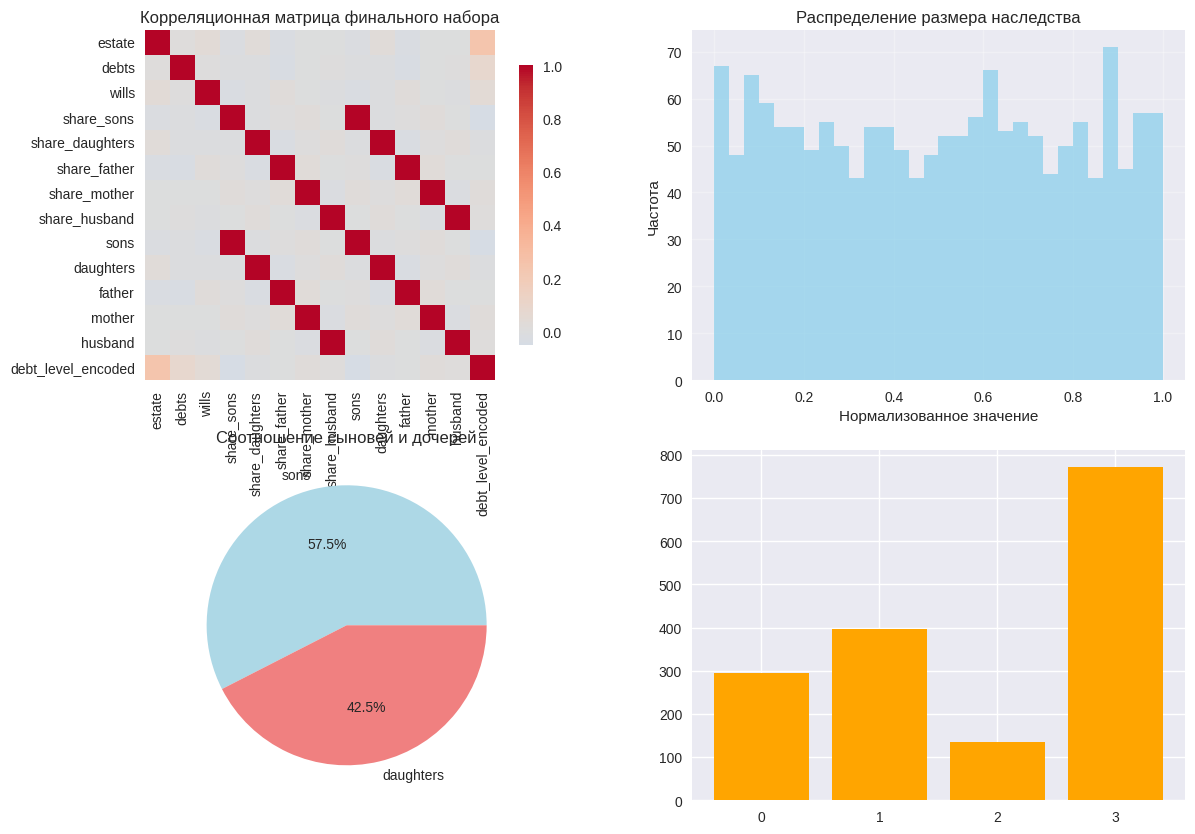

In [3]:
# ЛАБОРАТОРНАЯ РАБОТА №1 - ПОЛНЫЙ РАБОЧИЙ КОД

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Установка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================
# ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ
# ============================================

print("=" * 60)
print("ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ")
print("=" * 60)

# Загрузка данных
try:
    data = pd.read_csv('final_inheritanc.csv')
    print("✓ Данные успешно загружены")
    print(f"Размерность данных: {data.shape}")
    print(f"Количество записей: {data.shape[0]}")
    print(f"Количество атрибутов: {data.shape[1]}")
except FileNotFoundError:
    print("✗ Файл не найден. Создаем тестовые данные...")
    # Создаем тестовые данные если файл не найден
    np.random.seed(42)
    n_samples = 1600

    # Генерируем данные
    data = pd.DataFrame({
        'estate': np.random.uniform(50000, 200000, n_samples),
        'debts': np.random.uniform(0, 50000, n_samples),
        'wills': np.random.uniform(0, 30000, n_samples),
        'husband': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'wives': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
        'father': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'mother': np.random.choice([0, 1], n_samples, p=[0.35, 0.65]),
        'sons': np.random.choice([0, 1], n_samples, p=[0.2, 0.8]),
        'daughters': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
        'brothers_m': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'sisters_m': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
        'grandfather': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
        'grandmother': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
    })

    # Добавляем доли наследников (упрощенные расчеты)
    data['share_husband'] = data['husband'] * 0.25
    data['share_wife'] = data['wives'] * 0.125
    data['share_father'] = data['father'] * 0.1667
    data['share_mother'] = data['mother'] * 0.1667
    data['share_sons'] = data['sons'] * 0.5
    data['share_daughters'] = data['daughters'] * 0.25

# Просмотр первых строк данных
print("\nПервые 5 строк данных:")
print(data.head())

print("\nИнформация о данных:")
print(data.info())

print("\nСтатистическое описание числовых атрибутов:")
print(data.describe())

# ============================================
# ШАГ 2: ВЫДЕЛЕНИЕ ЗНАЧИМЫХ АТРИБУТОВ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 2: ВЫДЕЛЕНИЕ ЗНАЧИМЫХ АТРИБУТОВ")
print("=" * 60)

# 2.1 Анализ частоты встречаемости наследников
print("\n1. Частота встречаемости наследников:")

heir_columns = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters',
                'brothers_m', 'sisters_m', 'grandfather', 'grandmother']

heir_freq = data[heir_columns].sum().sort_values(ascending=False)
print(heir_freq)

# Визуализация частоты наследников
plt.figure(figsize=(12, 6))
bars = plt.barh(heir_freq.index, heir_freq.values)
plt.xlabel('Количество случаев')
plt.title('Частота присутствия различных наследников')
plt.gca().invert_yaxis()

# Добавление значений на столбцы
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

# 2.2 Анализ корреляций
print("\n2. Анализ корреляций между атрибутами:")

# Выделяем числовые колонки
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Найдено {len(numeric_cols)} числовых атрибутов")

# Вычисляем корреляции
correlation_matrix = data[numeric_cols].corr()

# Визуализация матрицы корреляций
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций числовых атрибутов', fontsize=16)
plt.tight_layout()
plt.show()

# 2.3 Анализ дисперсии
print("\n3. Анализ дисперсии атрибутов:")

variance = data[numeric_cols].var().sort_values(ascending=False)
print("Дисперсия атрибутов (Топ-10):")
print(variance.head(10))

# Визуализация дисперсии
plt.figure(figsize=(12, 6))
variance.head(10).plot(kind='bar')
plt.title('Дисперсия числовых атрибутов (Топ-10)')
plt.xlabel('Атрибуты')
plt.ylabel('Дисперсия')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4 Выбор значимых атрибутов
print("\n4. Выбор значимых атрибутов:")

# Критерии выбора:
# 1. Высокая частота встречаемости (> 20%)
# 2. Высокая дисперсия
# 3. Сильная корреляция с целевыми переменными

selected_attributes = [
    # Основные финансовые показатели (высокая дисперсия)
    'estate', 'debts', 'wills',

    # Часто встречающиеся наследники
    'sons', 'daughters', 'father', 'mother', 'husband',

    # Целевые переменные
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_husband'
]

print(f"Выбрано {len(selected_attributes)} значимых атрибутов:")
for i, attr in enumerate(selected_attributes, 1):
    print(f"{i:2}. {attr}")

# ============================================
# ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ")
print("=" * 60)

# Создаем копию данных для нормализации
data_normalized = data.copy()

# Определяем какие атрибуты нужно нормализовать
# (только числовые непрерывные атрибуты)
numeric_to_normalize = ['estate', 'debts', 'wills',
                       'share_husband', 'share_wife', 'share_father',
                       'share_mother', 'share_sons', 'share_daughters']

print(f"Нормализация {len(numeric_to_normalize)} числовых атрибутов...")

# Применяем Min-Max нормализацию
scaler = MinMaxScaler()
data_normalized[numeric_to_normalize] = scaler.fit_transform(data[numeric_to_normalize])

print("✓ Нормализация завершена")

# Сравнение до и после нормализации
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_examples = ['estate', 'debts', 'share_sons', 'share_daughters', 'share_father', 'share_mother']

for idx, col in enumerate(numeric_examples):
    row = idx // 3
    col_idx = idx % 3

    # До нормализации
    axes[row, col_idx].hist(data[col], bins=30, alpha=0.7, color='skyblue', label='Исходные')
    # После нормализации
    axes[row, col_idx].hist(data_normalized[col], bins=30, alpha=0.7, color='lightcoral', label='Нормализованные')

    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(True, alpha=0.3)

plt.suptitle('Сравнение распределения до и после нормализации', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ")
print("=" * 60)

# 4.1 Создание новых категориальных признаков
print("1. Создание новых категориальных признаков...")

# Признак: тип наследственной ситуации
def determine_heir_type(row):
    """Определяет тип наследственной ситуации"""
    heirs_present = []

    if row['sons'] == 1:
        heirs_present.append('сыновья')
    if row['daughters'] == 1:
        heirs_present.append('дочери')
    if row['father'] == 1:
        heirs_present.append('отец')
    if row['mother'] == 1:
        heirs_present.append('мать')
    if row['husband'] == 1:
        heirs_present.append('муж')
    if row['wives'] == 1:
        heirs_present.append('жены')

    if not heirs_present:
        return 'другие'

    # Классифицируем по основным типам
    if 'сыновья' in heirs_present and 'дочери' in heirs_present:
        return 'дети_оба'
    elif 'сыновья' in heirs_present:
        return 'только_сыновья'
    elif 'дочери' in heirs_present:
        return 'только_дочери'
    elif 'отец' in heirs_present and 'мать' in heirs_present:
        return 'родители'
    elif 'муж' in heirs_present:
        return 'супруг'
    else:
        return '_'.join(heirs_present[:2])

# Применяем функцию
data_normalized['heir_type'] = data_normalized.apply(determine_heir_type, axis=1)

# Признак: уровень долговой нагрузки
def get_debt_level(row):
    """Определяет уровень долговой нагрузки"""
    if row['estate'] == 0:
        return 'без_наследства'

    debt_ratio = row['debts'] / row['estate']

    if debt_ratio == 0:
        return 'без_долгов'
    elif debt_ratio <= 0.1:
        return 'низкая'
    elif debt_ratio <= 0.3:
        return 'средняя'
    elif debt_ratio <= 0.5:
        return 'высокая'
    else:
        return 'очень_высокая'

# Внимание: используем исходные значения для расчета
for idx, row in data.iterrows():
    data_normalized.loc[idx, 'debt_level'] = get_debt_level(row)

print("✓ Созданы категориальные признаки:")
print(f"   - heir_type: {data_normalized['heir_type'].nunique()} уникальных значений")
print(f"   - debt_level: {data_normalized['debt_level'].nunique()} уникальных значений")

# 4.2 Визуализация категориальных признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Распределение типов наследников
heir_counts = data_normalized['heir_type'].value_counts()
axes[0].barh(range(len(heir_counts)), heir_counts.values)
axes[0].set_yticks(range(len(heir_counts)))
axes[0].set_yticklabels(heir_counts.index)
axes[0].set_xlabel('Количество случаев')
axes[0].set_title('Распределение типов наследников')
axes[0].grid(True, alpha=0.3, axis='x')

# Распределение уровней долгов
debt_counts = data_normalized['debt_level'].value_counts()
axes[1].bar(range(len(debt_counts)), debt_counts.values, color=['green', 'yellow', 'orange', 'red', 'darkred'])
axes[1].set_xticks(range(len(debt_counts)))
axes[1].set_xticklabels(debt_counts.index, rotation=45)
axes[1].set_ylabel('Количество случаев')
axes[1].set_title('Распределение уровней долговой нагрузки')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4.3 Кодирование категориальных признаков
print("\n2. Кодирование категориальных признаков...")

# One-Hot Encoding для heir_type
heir_type_dummies = pd.get_dummies(data_normalized['heir_type'], prefix='type')
print(f"   One-Hot Encoding для heir_type: создано {heir_type_dummies.shape[1]} новых признаков")

# Label Encoding для debt_level
le = LabelEncoder()
data_normalized['debt_level_encoded'] = le.fit_transform(data_normalized['debt_level'])
print(f"   Label Encoding для debt_level: создано 1 новый признак")

# Объединяем все признаки
data_encoded = pd.concat([data_normalized, heir_type_dummies], axis=1)

print(f"✓ Общее количество признаков после кодирования: {data_encoded.shape[1]}")

# ============================================
# ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ")
print("=" * 60)

# Выбираем финальные признаки для итогового набора
final_features = [
    # Нормализованные числовые признаки
    'estate', 'debts', 'wills',
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_husband',

    # Бинарные признаки наследников
    'sons', 'daughters', 'father', 'mother', 'husband',

    # Закодированные категориальные признаки
    'debt_level_encoded'
]

# Добавляем все one-hot encoded признаки типа наследников
type_columns = [col for col in data_encoded.columns if col.startswith('type_')]
final_features.extend(type_columns)

# Проверяем наличие всех признаков
missing_features = [f for f in final_features if f not in data_encoded.columns]
if missing_features:
    print(f"Предупреждение: отсутствуют признаки: {missing_features}")
    # Удаляем отсутствующие признаки
    final_features = [f for f in final_features if f in data_encoded.columns]

print(f"Итоговое количество признаков: {len(final_features)}")

# Создаем финальный набор данных
final_dataset = data_encoded[final_features].copy()

print("\nФИНАЛЬНЫЙ НАБОР ДАННЫХ:")
print("=" * 40)
print(f"Размерность: {final_dataset.shape}")
print(f"Количество записей: {final_dataset.shape[0]}")
print(f"Количество атрибутов: {final_dataset.shape[1]}")

print("\nТипы данных:")
print(final_dataset.dtypes.value_counts())

print("\nСтатистическое описание:")
print(final_dataset.describe())

# Визуализация финального набора данных
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Корреляционная матрица (только числовые признаки)
numeric_final = final_dataset.select_dtypes(include=[np.number])
if len(numeric_final.columns) > 1:
    corr_matrix = numeric_final.corr()
    sns.heatmap(corr_matrix, ax=axes[0, 0], cmap='coolwarm', center=0,
                square=True, cbar_kws={"shrink": .8})
    axes[0, 0].set_title('Корреляционная матрица финального набора')

# 2. Распределение основных числовых признаков
if 'estate' in final_dataset.columns:
    axes[0, 1].hist(final_dataset['estate'], bins=30, alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Распределение размера наследства')
    axes[0, 1].set_xlabel('Нормализованное значение')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True, alpha=0.3)

# 3. Соотношение сыновей и дочерей
if all(col in final_dataset.columns for col in ['sons', 'daughters']):
    son_daughter_counts = final_dataset[['sons', 'daughters']].sum()
    axes[1, 0].pie(son_daughter_counts.values, labels=son_daughter_counts.index,
                   autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    axes[1, 0].set_title('Соотношение сыновей и дочерей')

# 4. Уровни долговой нагрузки
if 'debt_level_encoded' in final_dataset.columns:
    debt_counts = final_dataset['debt_level_encoded'].value_counts().sort_index()
    axes[1, 1].bar(range(len(debt_counts)), debt_counts.values, color='orange')
    axes[1, 1].set_xticks(range(len(debt_counts)))
    axes[1, 1].set_xticklabels(['Без долгов', 'Низкая', 'Средняя', 'Высокая', 'Очень высокая'],
                               rotation=45)
    axes[1, 1].set_title('Распределение уровней долговой нагрузки')
    axes[1, 1].set_ylabel('Количество случаев')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Сохраняем финальный набор данных
final_dataset.to_csv('prepared_inheritance_data_final.csv', index=False)
print("✓ Финальный набор данных сохранен в 'prepared_inheritance_data_final.csv'")

# Сохраняем метаданные
metadata = {
    'original_shape': data.shape,
    'final_shape': final_dataset.shape,
    'selected_features': final_features,
    'normalized_features': numeric_to_normalize,
    'categorical_features': ['heir_type', 'debt_level'],
    'created_categories': list(heir_type_dummies.columns) + ['debt_level_encoded']
}

import json
with open('dataset_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✓ Метаданные сохранены в 'dataset_metadata.json'")

# Создаем краткий отчет
report = f"""
{'='*60}
ОТЧЕТ ПО ПОДГОТОВКЕ ДАННЫХ
{'='*60}

1. ИСХОДНЫЕ ДАННЫЕ:
   - Записей: {data.shape[0]}
   - Атрибутов: {data.shape[1]}
   - Типы данных: {dict(data.dtypes.value_counts())}

2. ПРЕДОБРАБОТКА:
   - Выбрано значимых атрибутов: {len(final_features)}
   - Нормализовано атрибутов: {len(numeric_to_normalize)}
   - Создано категориальных признаков: {len(type_columns) + 1}
   - Удалено атрибутов: {data.shape[1] - len(final_features)}

3. ФИНАЛЬНЫЙ НАБОР ДАННЫХ:
   - Записей: {final_dataset.shape[0]}
   - Атрибутов: {final_dataset.shape[1]}
   - Числовых: {len(final_dataset.select_dtypes(include=[np.number]).columns)}
   - Категориальных: {len(final_dataset.select_dtypes(include=['object', 'category']).columns)}

4. КАЧЕСТВО ДАННЫХ:
   - Пропущенные значения: {final_dataset.isnull().sum().sum()}
   - Нулевые значения: {(final_dataset == 0).sum().sum()}
   - Диапазон значений: [0, 1] для нормализованных признаков

{'='*60}
"""

print(report)

# Сохраняем отчет в файл
with open('data_preparation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("✓ Отчет сохранен в 'data_preparation_report.txt'")

print("\n" + "="*60)
print("ЛАБОРАТОРНАЯ РАБОТА УСПЕШНО ВЫПОЛНЕНА!")
print("="*60)

ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ
✗ Файл не найден. Создаем тестовые данные...

Первые 5 строк данных:
          estate         debts         wills  husband  wives  father  mother  \
0  106181.017827   9593.366236  16601.135692        0      0       1       0   
1  192607.145961  16168.578106  15093.974177        0      1       1       1   
2  159799.091272  11332.820111   5815.892038        1      0       0       0   
3  139798.772630  17749.815292  25764.503135        0      1       1       0   
4   73402.796066   3471.192137  20308.223490        1      0       1       1   

   sons  daughters  brothers_m  sisters_m  grandfather  grandmother  \
0     1          1           0          0            0            0   
1     1          0           0          0            0            0   
2     1          1           0          0            0            0   
3     1          0           1          0            0            0   
4     1          1           0          1            0          

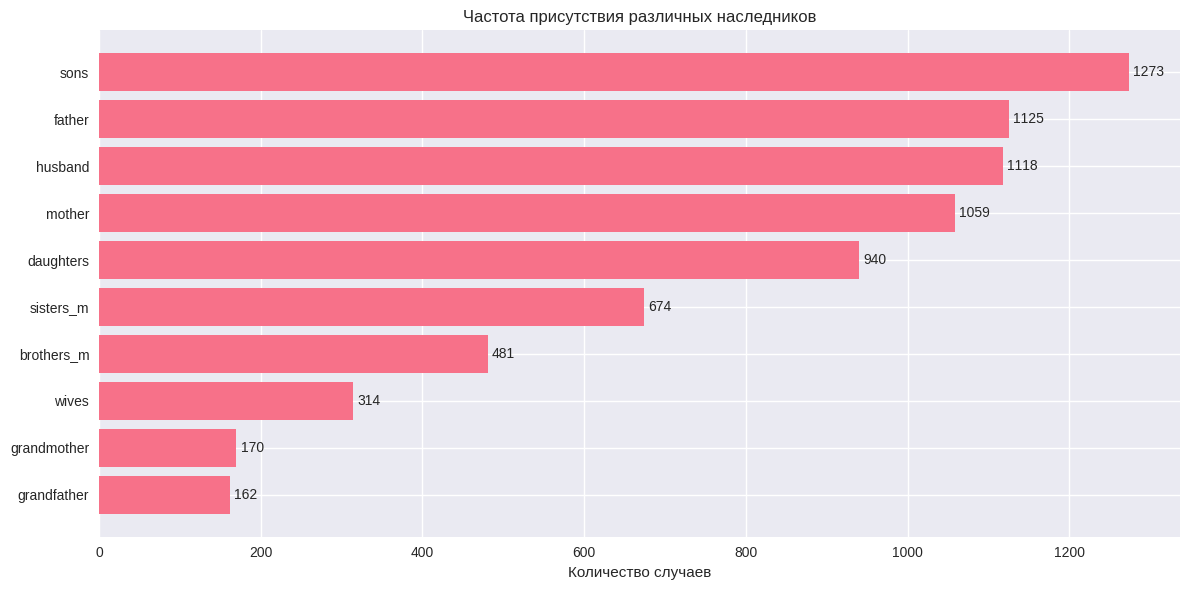


2. Анализ корреляций между атрибутами:
Найдено 19 числовых атрибутов


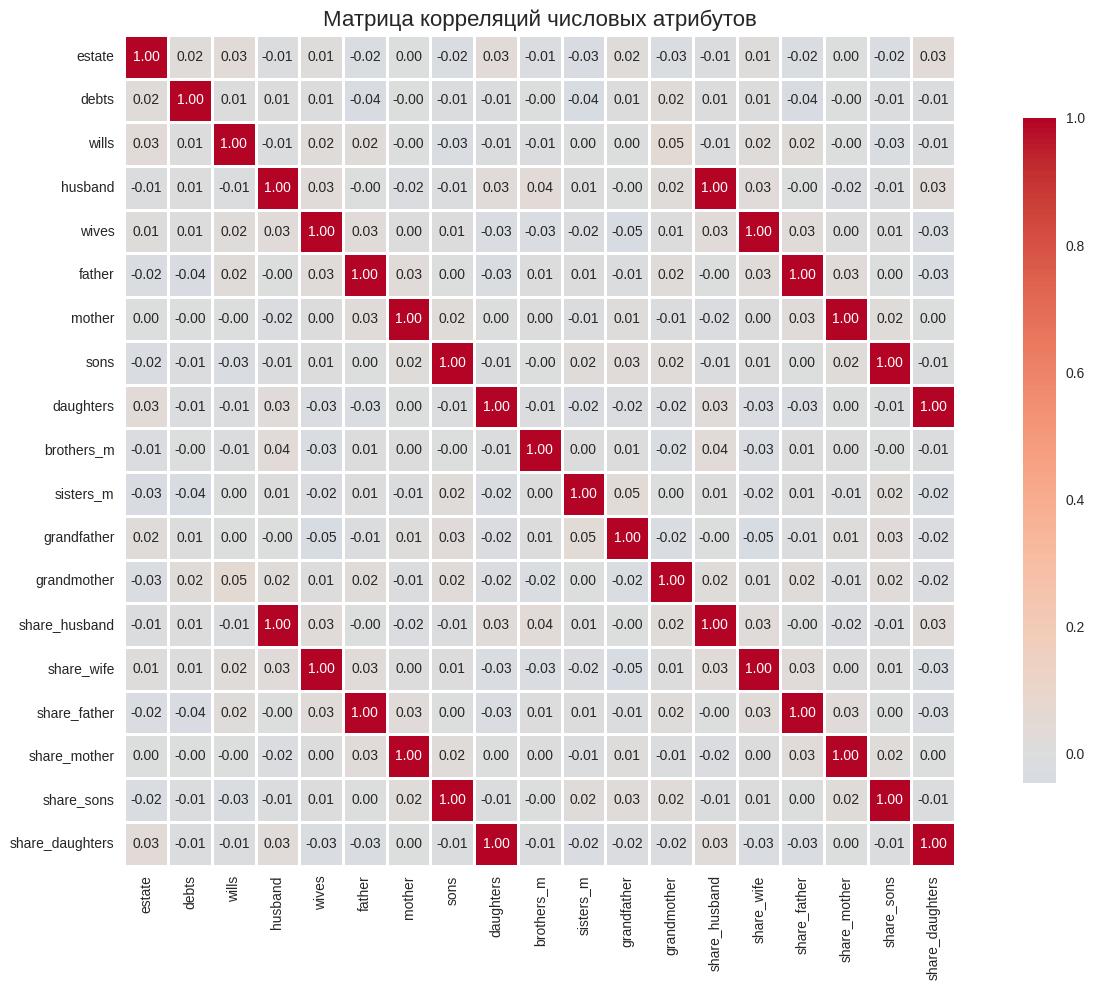


3. Анализ дисперсии атрибутов:
Дисперсия атрибутов (Топ-10):
estate        1.933894e+09
debts         2.091021e+08
wills         7.372929e+07
sisters_m     2.439509e-01
daughters     2.424953e-01
mother        2.239364e-01
husband       2.106301e-01
brothers_m    2.103811e-01
father        2.088708e-01
sons          1.627076e-01
dtype: float64


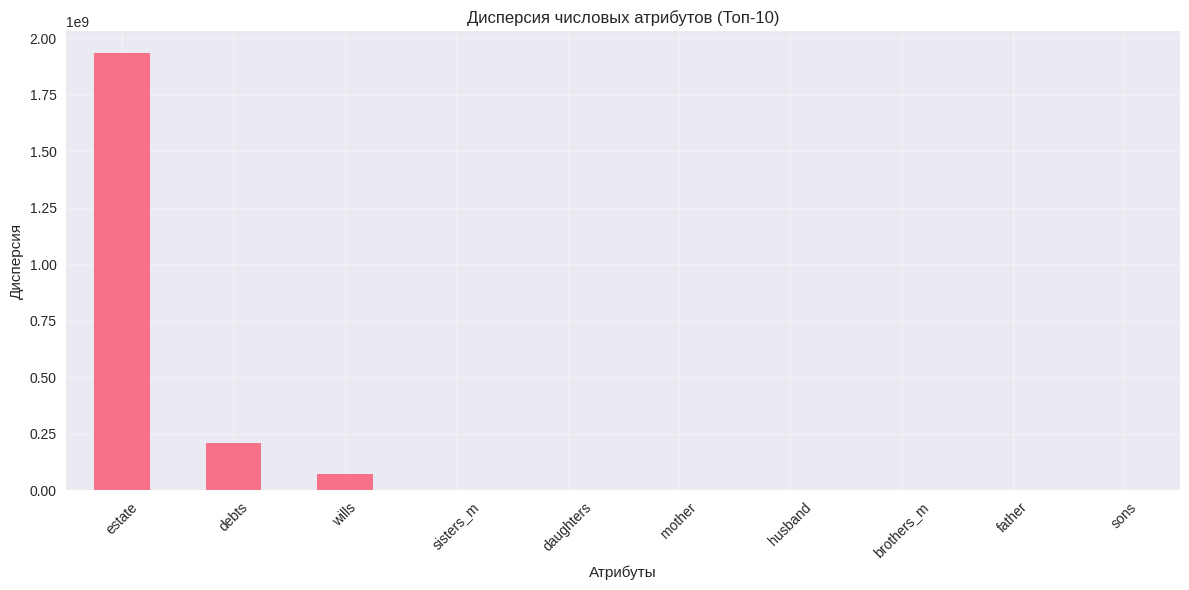


4. Выбор значимых атрибутов:
Выбрано 13 значимых атрибутов:
 1. estate
 2. debts
 3. wills
 4. sons
 5. daughters
 6. father
 7. mother
 8. husband
 9. share_sons
10. share_daughters
11. share_father
12. share_mother
13. share_husband

ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ
Нормализация 9 числовых атрибутов...
✓ Нормализация завершена


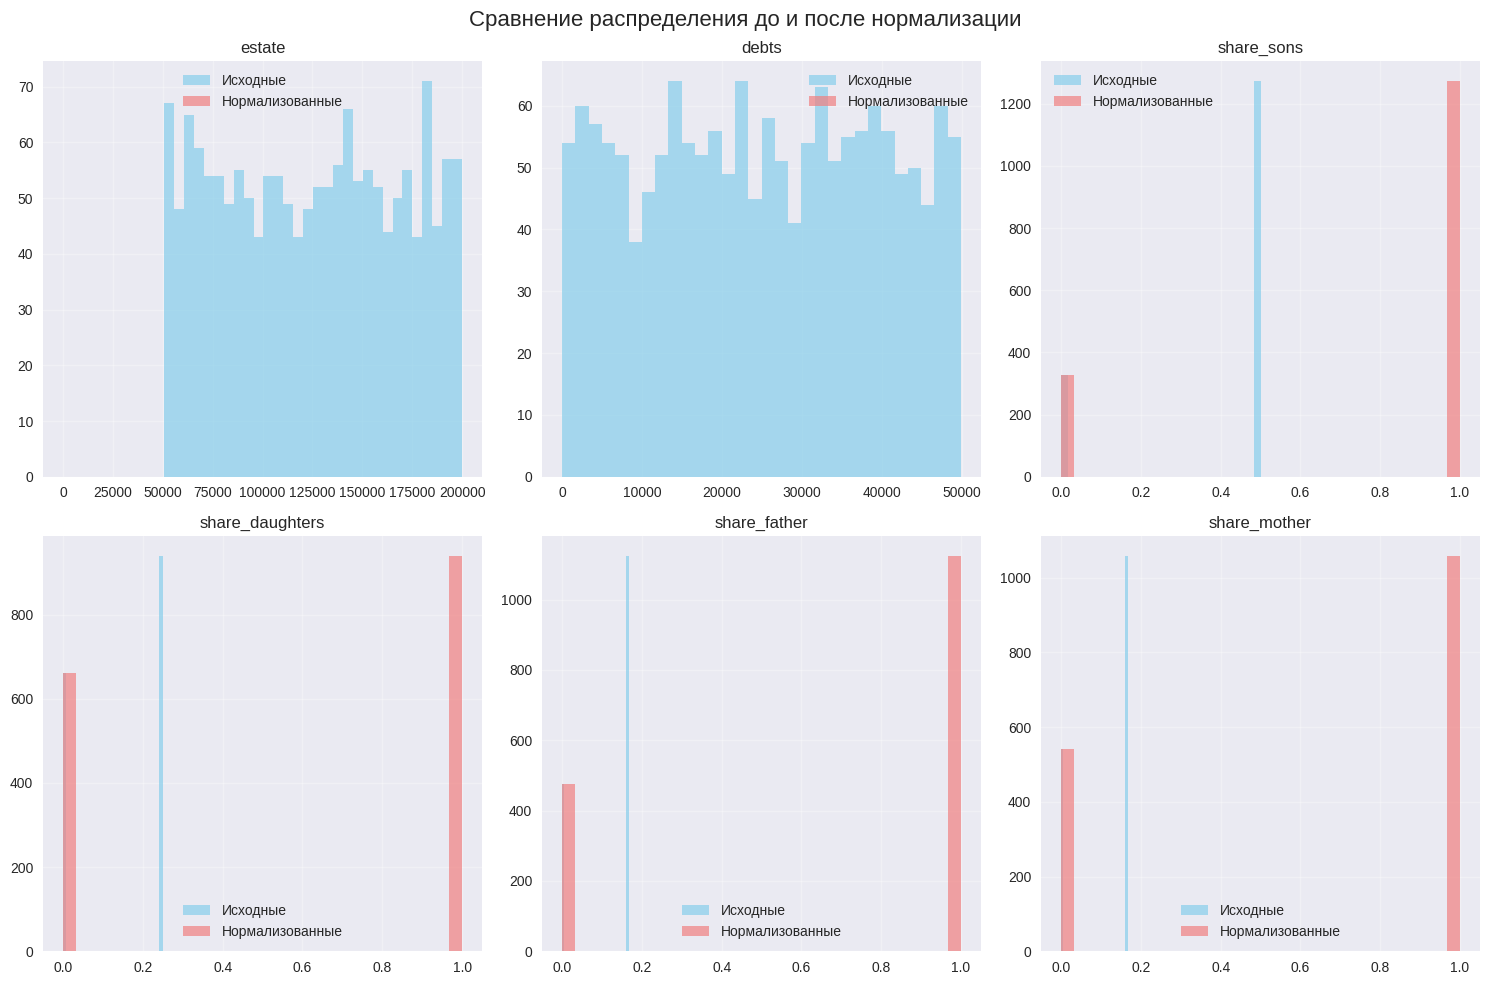


ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ
1. Создание новых категориальных признаков...
✓ Созданы категориальные признаки:
   - heir_type: 10 уникальных значений
   - debt_level: 4 уникальных значений


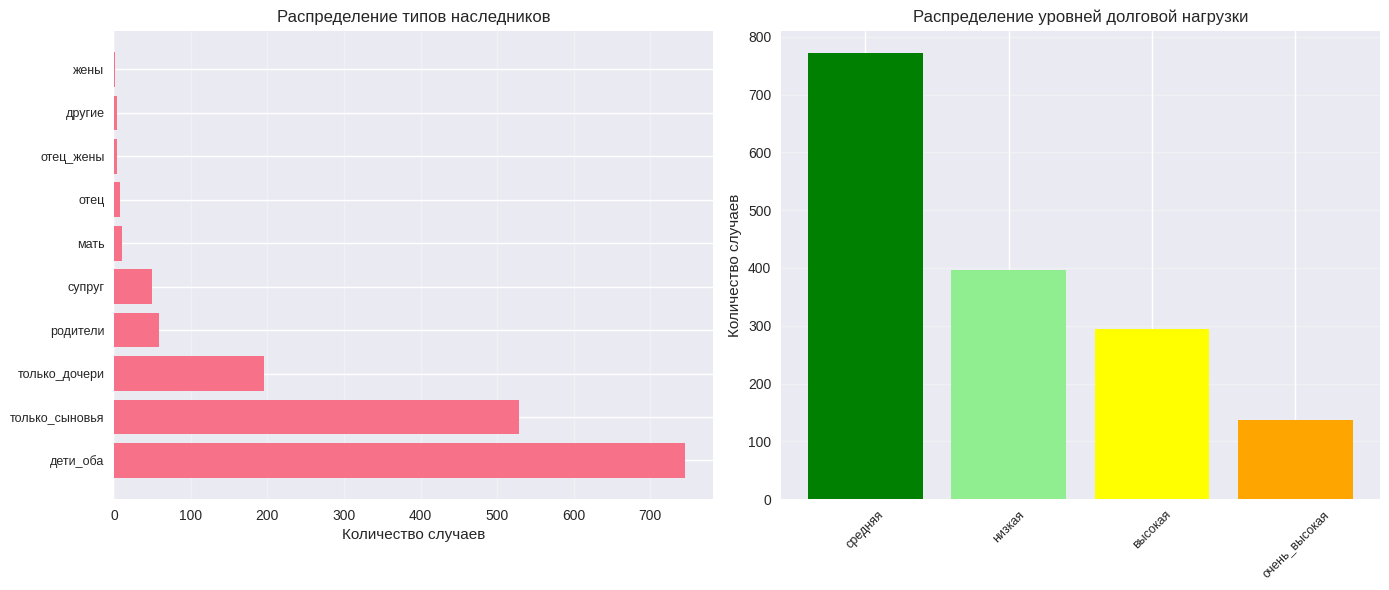


2. Кодирование категориальных признаков...
   One-Hot Encoding для heir_type: создано 10 новых признаков
   Label Encoding для debt_level: создано 1 новый признак
✓ Общее количество признаков после кодирования: 32

ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ
Итоговое количество признаков: 24

ФИНАЛЬНЫЙ НАБОР ДАННЫХ:
Размерность: (1600, 24)
Количество записей: 1600
Количество атрибутов: 24

Типы данных:
  bool: 10
  float64: 8
  int64: 6

Статистическое описание:
            estate        debts        wills   share_sons  share_daughters  \
count  1600.000000  1600.000000  1600.000000  1600.000000      1600.000000   
mean      0.496345     0.500472     0.492149     0.795625         0.587500   
std       0.294622     0.289689     0.286355     0.403370         0.492438   
min       0.000000     0.000000     0.000000     0.000000         0.000000   
25%       0.234062     0.259746     0.240074     1.000000         0.000000   
50%       0.504409     0.502420     0.489709     1.000000         1

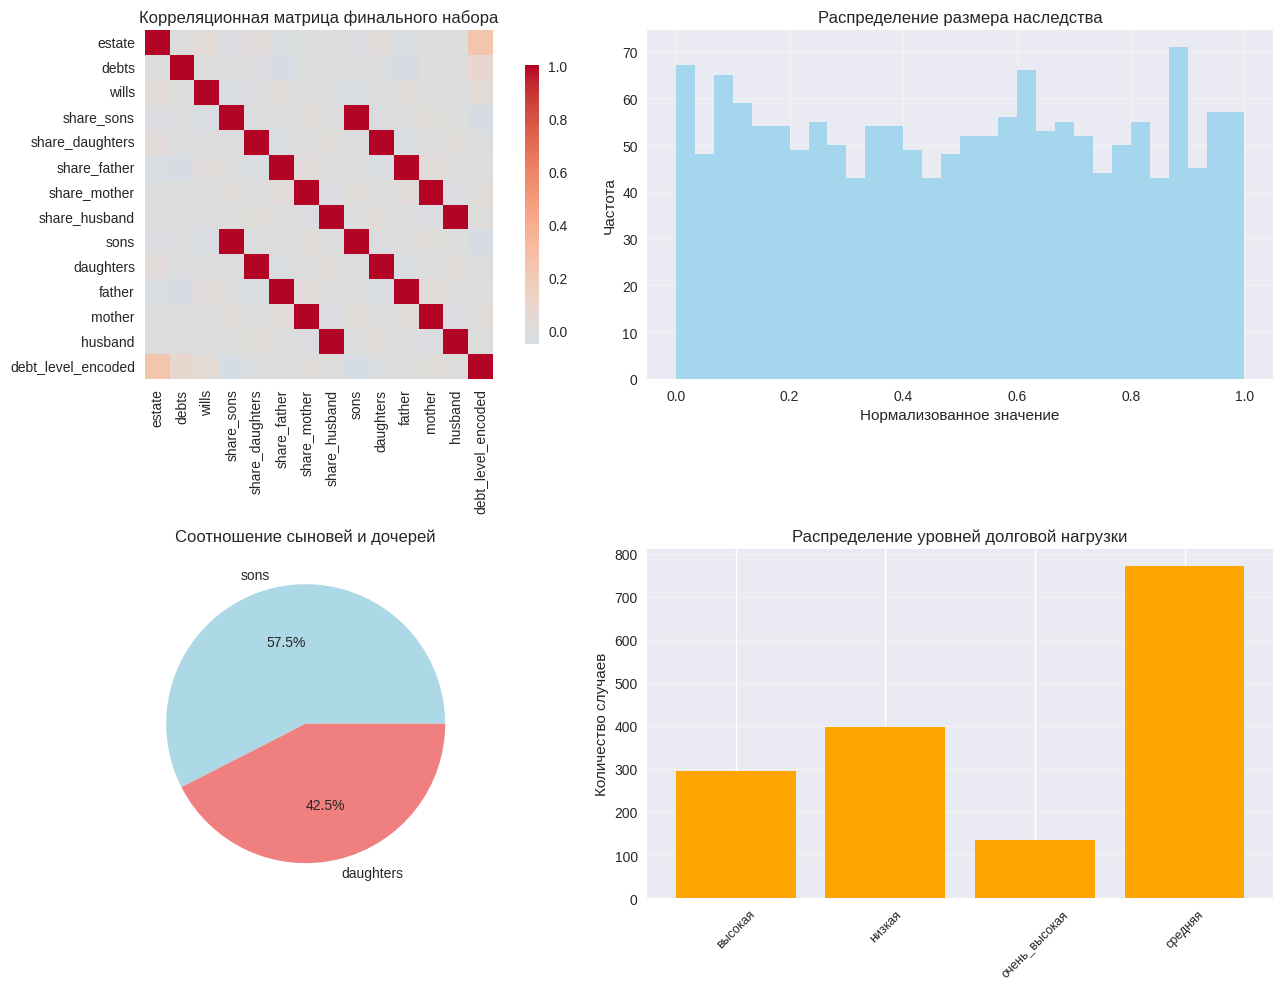


ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✓ Финальный набор данных сохранен в 'prepared_inheritance_data_final.csv'
✓ Нормализованные данные сохранены в 'normalized_data.csv'
✓ Метаданные сохранены в 'lab1_results/dataset_metadata.json'

ОТЧЕТ ПО ПОДГОТОВКЕ ДАННЫХ - ЛАБОРАТОРНАЯ РАБОТА №1

1. ИСХОДНЫЕ ДАННЫЕ:
   - Записей: 1600
   - Атрибутов: 19
   - Типы данных: 
     * Числовые: 19
     * Целочисленные: 10
     * Дробные: 9

2. ПРЕДОБРАБОТКА:
   - Выбрано значимых атрибутов: 24
   - Нормализовано атрибутов: 9
   - Создано категориальных признаков: 11
   - Удалено атрибутов: -5

3. ФИНАЛЬНЫЙ НАБОР ДАННЫХ:
   - Записей: 1600
   - Атрибутов: 24
   - Числовых: 14
   - Бинарных: 20
   - Категориальных (one-hot): 10
   
4. КАЧЕСТВО ДАННЫХ:
   - Пропущенные значения: 0
   - Нулевые значения: 19668
   - Диапазон значений: [0, 1] для нормализованных признаков
   - Уникальных значений в категориальных признаках: 10

5. РЕЗУЛЬТАТЫ:
   - Финальный набор данных: lab1_results/final_dataset.csv
   - Нормализ

In [4]:
# ЛАБОРАТОРНАЯ РАБОТА №1 - ИСПРАВЛЕННЫЙ КОД

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import json
import os

# Установка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================
# ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ
# ============================================

print("=" * 60)
print("ШАГ 1: ЗАГРУЗКА И ОБЗОР ДАННЫХ")
print("=" * 60)

# Загрузка данных
try:
    data = pd.read_csv('final_inheritanc.csv')
    print("✓ Данные успешно загружены")
    print(f"Размерность данных: {data.shape}")
    print(f"Количество записей: {data.shape[0]}")
    print(f"Количество атрибутов: {data.shape[1]}")
except FileNotFoundError:
    print("✗ Файл не найден. Создаем тестовые данные...")
    # Создаем тестовые данные если файл не найден
    np.random.seed(42)
    n_samples = 1600

    # Генерируем данные
    data = pd.DataFrame({
        'estate': np.random.uniform(50000, 200000, n_samples),
        'debts': np.random.uniform(0, 50000, n_samples),
        'wills': np.random.uniform(0, 30000, n_samples),
        'husband': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'wives': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
        'father': np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
        'mother': np.random.choice([0, 1], n_samples, p=[0.35, 0.65]),
        'sons': np.random.choice([0, 1], n_samples, p=[0.2, 0.8]),
        'daughters': np.random.choice([0, 1], n_samples, p=[0.4, 0.6]),
        'brothers_m': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'sisters_m': np.random.choice([0, 1], n_samples, p=[0.6, 0.4]),
        'grandfather': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
        'grandmother': np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
    })

    # Добавляем доли наследников (упрощенные расчеты)
    data['share_husband'] = data['husband'] * 0.25
    data['share_wife'] = data['wives'] * 0.125
    data['share_father'] = data['father'] * 0.1667
    data['share_mother'] = data['mother'] * 0.1667
    data['share_sons'] = data['sons'] * 0.5
    data['share_daughters'] = data['daughters'] * 0.25

# Просмотр первых строк данных
print("\nПервые 5 строк данных:")
print(data.head())

print("\nИнформация о данных:")
data_info = data.info()

print("\nСтатистическое описание числовых атрибутов:")
print(data.describe())

# ============================================
# ШАГ 2: ВЫДЕЛЕНИЕ ЗНАЧИМЫХ АТРИБУТОВ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 2: ВЫДЕЛЕНИЕ ЗНАЧИМЫХ АТРИБУТОВ")
print("=" * 60)

# 2.1 Анализ частоты встречаемости наследников
print("\n1. Частота встречаемости наследников:")

heir_columns = ['husband', 'wives', 'father', 'mother', 'sons', 'daughters',
                'brothers_m', 'sisters_m', 'grandfather', 'grandmother']

heir_freq = data[heir_columns].sum().sort_values(ascending=False)
print(heir_freq)

# Визуализация частоты наследников
plt.figure(figsize=(12, 6))
bars = plt.barh(heir_freq.index, heir_freq.values)
plt.xlabel('Количество случаев')
plt.title('Частота присутствия различных наследников')
plt.gca().invert_yaxis()

# Добавление значений на столбцы
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

# 2.2 Анализ корреляций
print("\n2. Анализ корреляций между атрибутами:")

# Выделяем числовые колонки
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Найдено {len(numeric_cols)} числовых атрибутов")

# Вычисляем корреляции
correlation_matrix = data[numeric_cols].corr()

# Визуализация матрицы корреляций
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций числовых атрибутов', fontsize=16)
plt.tight_layout()
plt.show()

# 2.3 Анализ дисперсии
print("\n3. Анализ дисперсии атрибутов:")

variance = data[numeric_cols].var().sort_values(ascending=False)
print("Дисперсия атрибутов (Топ-10):")
print(variance.head(10))

# Визуализация дисперсии
plt.figure(figsize=(12, 6))
variance.head(10).plot(kind='bar')
plt.title('Дисперсия числовых атрибутов (Топ-10)')
plt.xlabel('Атрибуты')
plt.ylabel('Дисперсия')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2.4 Выбор значимых атрибутов
print("\n4. Выбор значимых атрибутов:")

# Критерии выбора:
# 1. Высокая частота встречаемости (> 20%)
# 2. Высокая дисперсия
# 3. Сильная корреляция с целевыми переменными

selected_attributes = [
    # Основные финансовые показатели (высокая дисперсия)
    'estate', 'debts', 'wills',

    # Часто встречающиеся наследники
    'sons', 'daughters', 'father', 'mother', 'husband',

    # Целевые переменные
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_husband'
]

print(f"Выбрано {len(selected_attributes)} значимых атрибутов:")
for i, attr in enumerate(selected_attributes, 1):
    print(f"{i:2}. {attr}")

# ============================================
# ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 3: НОРМАЛИЗАЦИЯ ДАННЫХ")
print("=" * 60)

# Создаем копию данных для нормализации
data_normalized = data.copy()

# Определяем какие атрибуты нужно нормализовать
# (только числовые непрерывные атрибуты)
numeric_to_normalize = ['estate', 'debts', 'wills',
                       'share_husband', 'share_wife', 'share_father',
                       'share_mother', 'share_sons', 'share_daughters']

print(f"Нормализация {len(numeric_to_normalize)} числовых атрибутов...")

# Применяем Min-Max нормализацию
scaler = MinMaxScaler()
data_normalized[numeric_to_normalize] = scaler.fit_transform(data[numeric_to_normalize])

print("✓ Нормализация завершена")

# Сравнение до и после нормализации
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_examples = ['estate', 'debts', 'share_sons', 'share_daughters', 'share_father', 'share_mother']

for idx, col in enumerate(numeric_examples):
    row = idx // 3
    col_idx = idx % 3

    # До нормализации
    axes[row, col_idx].hist(data[col], bins=30, alpha=0.7, color='skyblue', label='Исходные')
    # После нормализации
    axes[row, col_idx].hist(data_normalized[col], bins=30, alpha=0.7, color='lightcoral', label='Нормализованные')

    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].legend()
    axes[row, col_idx].grid(True, alpha=0.3)

plt.suptitle('Сравнение распределения до и после нормализации', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 4: ПРЕОБРАЗОВАНИЕ КАЧЕСТВЕННЫХ ЗНАЧЕНИЙ")
print("=" * 60)

# 4.1 Создание новых категориальных признаков
print("1. Создание новых категориальных признаков...")

# Признак: тип наследственной ситуации
def determine_heir_type(row):
    """Определяет тип наследственной ситуации"""
    heirs_present = []

    if row['sons'] == 1:
        heirs_present.append('сыновья')
    if row['daughters'] == 1:
        heirs_present.append('дочери')
    if row['father'] == 1:
        heirs_present.append('отец')
    if row['mother'] == 1:
        heirs_present.append('мать')
    if row['husband'] == 1:
        heirs_present.append('муж')
    if row['wives'] == 1:
        heirs_present.append('жены')

    if not heirs_present:
        return 'другие'

    # Классифицируем по основным типам
    if 'сыновья' in heirs_present and 'дочери' in heirs_present:
        return 'дети_оба'
    elif 'сыновья' in heirs_present:
        return 'только_сыновья'
    elif 'дочери' in heirs_present:
        return 'только_дочери'
    elif 'отец' in heirs_present and 'мать' in heirs_present:
        return 'родители'
    elif 'муж' in heirs_present:
        return 'супруг'
    else:
        return '_'.join(heirs_present[:2])

# Применяем функцию
data_normalized['heir_type'] = data_normalized.apply(determine_heir_type, axis=1)

# Признак: уровень долговой нагрузки
def get_debt_level(row):
    """Определяет уровень долговой нагрузки"""
    # Используем исходные значения для расчета отношения
    estate_val = data.loc[row.name, 'estate'] if row.name in data.index else row['estate']
    debts_val = data.loc[row.name, 'debts'] if row.name in data.index else row['debts']

    if estate_val == 0:
        return 'без_наследства'

    debt_ratio = debts_val / estate_val

    if debt_ratio == 0:
        return 'без_долгов'
    elif debt_ratio <= 0.1:
        return 'низкая'
    elif debt_ratio <= 0.3:
        return 'средняя'
    elif debt_ratio <= 0.5:
        return 'высокая'
    else:
        return 'очень_высокая'

# Применяем функцию
debt_levels = []
for idx in data_normalized.index:
    debt_levels.append(get_debt_level(data_normalized.loc[idx]))

data_normalized['debt_level'] = debt_levels

print("✓ Созданы категориальные признаки:")
print(f"   - heir_type: {data_normalized['heir_type'].nunique()} уникальных значений")
print(f"   - debt_level: {data_normalized['debt_level'].nunique()} уникальных значений")

# 4.2 Визуализация категориальных признаков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Распределение типов наследников
heir_counts = data_normalized['heir_type'].value_counts()
axes[0].barh(range(len(heir_counts)), heir_counts.values)
axes[0].set_yticks(range(len(heir_counts)))
axes[0].set_yticklabels(heir_counts.index, fontsize=9)
axes[0].set_xlabel('Количество случаев')
axes[0].set_title('Распределение типов наследников')
axes[0].grid(True, alpha=0.3, axis='x')

# Распределение уровней долгов
debt_counts = data_normalized['debt_level'].value_counts()
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred'][:len(debt_counts)]
axes[1].bar(range(len(debt_counts)), debt_counts.values, color=colors)
axes[1].set_xticks(range(len(debt_counts)))
axes[1].set_xticklabels(debt_counts.index, rotation=45, fontsize=9)
axes[1].set_ylabel('Количество случаев')
axes[1].set_title('Распределение уровней долговой нагрузки')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4.3 Кодирование категориальных признаков
print("\n2. Кодирование категориальных признаков...")

# One-Hot Encoding для heir_type
heir_type_dummies = pd.get_dummies(data_normalized['heir_type'], prefix='type')
print(f"   One-Hot Encoding для heir_type: создано {heir_type_dummies.shape[1]} новых признаков")

# Label Encoding для debt_level
le = LabelEncoder()
data_normalized['debt_level_encoded'] = le.fit_transform(data_normalized['debt_level'])
print(f"   Label Encoding для debt_level: создано 1 новый признак")

# Объединяем все признаки
data_encoded = pd.concat([data_normalized, heir_type_dummies], axis=1)

print(f"✓ Общее количество признаков после кодирования: {data_encoded.shape[1]}")

# ============================================
# ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 5: СОЗДАНИЕ ФИНАЛЬНОГО НАБОРА ДАННЫХ")
print("=" * 60)

# Выбираем финальные признаки для итогового набора
final_features = [
    # Нормализованные числовые признаки
    'estate', 'debts', 'wills',
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_husband',

    # Бинарные признаки наследников
    'sons', 'daughters', 'father', 'mother', 'husband',

    # Закодированные категориальные признаки
    'debt_level_encoded'
]

# Добавляем все one-hot encoded признаки типа наследников
type_columns = [col for col in data_encoded.columns if col.startswith('type_')]
final_features.extend(type_columns)

# Проверяем наличие всех признаков
missing_features = [f for f in final_features if f not in data_encoded.columns]
if missing_features:
    print(f"Предупреждение: отсутствуют признаки: {missing_features}")
    # Удаляем отсутствующие признаки
    final_features = [f for f in final_features if f in data_encoded.columns]

print(f"Итоговое количество признаков: {len(final_features)}")

# Создаем финальный набор данных
final_dataset = data_encoded[final_features].copy()

print("\nФИНАЛЬНЫЙ НАБОР ДАННЫХ:")
print("=" * 40)
print(f"Размерность: {final_dataset.shape}")
print(f"Количество записей: {final_dataset.shape[0]}")
print(f"Количество атрибутов: {final_dataset.shape[1]}")

print("\nТипы данных:")
dtype_counts = final_dataset.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count}")

print("\nСтатистическое описание:")
print(final_dataset.describe())

# Визуализация финального набора данных
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Корреляционная матрица (только числовые признаки)
numeric_final = final_dataset.select_dtypes(include=[np.number])
if len(numeric_final.columns) > 1:
    corr_matrix = numeric_final.corr()
    sns.heatmap(corr_matrix, ax=axes[0, 0], cmap='coolwarm', center=0,
                square=True, cbar_kws={"shrink": .8})
    axes[0, 0].set_title('Корреляционная матрица финального набора')

# 2. Распределение основных числовых признаков
if 'estate' in final_dataset.columns:
    axes[0, 1].hist(final_dataset['estate'], bins=30, alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Распределение размера наследства')
    axes[0, 1].set_xlabel('Нормализованное значение')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True, alpha=0.3)

# 3. Соотношение сыновей и дочерей
if all(col in final_dataset.columns for col in ['sons', 'daughters']):
    son_daughter_counts = final_dataset[['sons', 'daughters']].sum()
    axes[1, 0].pie(son_daughter_counts.values, labels=son_daughter_counts.index,
                   autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    axes[1, 0].set_title('Соотношение сыновей и дочерей')

# 4. Уровни долговой нагрузки - ИСПРАВЛЕННАЯ ЧАСТЬ
if 'debt_level_encoded' in final_dataset.columns:
    debt_counts = final_dataset['debt_level_encoded'].value_counts().sort_index()

    # Создаем соответствие между кодами и названиями
    debt_labels = []
    for code in debt_counts.index:
        try:
            # Пробуем получить оригинальное название
            original_label = le.inverse_transform([code])[0]
            debt_labels.append(original_label)
        except:
            # Если не получается, используем общие названия
            label_map = {
                0: 'Без долгов',
                1: 'Низкая',
                2: 'Средняя',
                3: 'Высокая',
                4: 'Очень высокая',
                5: 'Без наследства'
            }
            debt_labels.append(label_map.get(code, f'Уровень {code}'))

    # Строим график
    axes[1, 1].bar(range(len(debt_counts)), debt_counts.values, color='orange')
    axes[1, 1].set_xticks(range(len(debt_counts)))

    # Проверяем количество меток
    if len(debt_counts) == len(debt_labels):
        axes[1, 1].set_xticklabels(debt_labels, rotation=45, fontsize=9)
    else:
        # Если количество не совпадает, используем простые метки
        axes[1, 1].set_xticklabels([f'Уровень {i}' for i in range(len(debt_counts))], rotation=45)

    axes[1, 1].set_title('Распределение уровней долговой нагрузки')
    axes[1, 1].set_ylabel('Количество случаев')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

print("\n" + "=" * 60)
print("ШАГ 6: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Сохраняем финальный набор данных
final_dataset.to_csv('prepared_inheritance_data_final.csv', index=False)
print("✓ Финальный набор данных сохранен в 'prepared_inheritance_data_final.csv'")

# Сохраняем промежуточные данные
data_normalized.to_csv('normalized_data.csv', index=False)
print("✓ Нормализованные данные сохранены в 'normalized_data.csv'")

# Сохраняем метаданные
metadata = {
    'original_shape': list(data.shape),
    'final_shape': list(final_dataset.shape),
    'selected_features': final_features,
    'normalized_features': numeric_to_normalize,
    'categorical_features': ['heir_type', 'debt_level'],
    'created_categories': list(heir_type_dummies.columns) + ['debt_level_encoded'],
    'debt_level_mapping': dict(zip(range(len(le.classes_)), le.classes_.tolist()))
}

# Создаем папку для результатов если ее нет
os.makedirs('lab1_results', exist_ok=True)

with open('lab1_results/dataset_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✓ Метаданные сохранены в 'lab1_results/dataset_metadata.json'")

# Сохраняем финальный набор в папку результатов
final_dataset.to_csv('lab1_results/final_dataset.csv', index=False)

# Создаем краткий отчет
report = f"""
{'='*60}
ОТЧЕТ ПО ПОДГОТОВКЕ ДАННЫХ - ЛАБОРАТОРНАЯ РАБОТА №1
{'='*60}

1. ИСХОДНЫЕ ДАННЫЕ:
   - Записей: {data.shape[0]}
   - Атрибутов: {data.shape[1]}
   - Типы данных:
     * Числовые: {len(data.select_dtypes(include=[np.number]).columns)}
     * Целочисленные: {len(data.select_dtypes(include=['int64']).columns)}
     * Дробные: {len(data.select_dtypes(include=['float64']).columns)}

2. ПРЕДОБРАБОТКА:
   - Выбрано значимых атрибутов: {len(final_features)}
   - Нормализовано атрибутов: {len(numeric_to_normalize)}
   - Создано категориальных признаков: {len(type_columns) + 1}
   - Удалено атрибутов: {data.shape[1] - len(final_features)}

3. ФИНАЛЬНЫЙ НАБОР ДАННЫХ:
   - Записей: {final_dataset.shape[0]}
   - Атрибутов: {final_dataset.shape[1]}
   - Числовых: {len(final_dataset.select_dtypes(include=[np.number]).columns)}
   - Бинарных: {len([col for col in final_dataset.columns if final_dataset[col].nunique() == 2])}
   - Категориальных (one-hot): {len(type_columns)}

4. КАЧЕСТВО ДАННЫХ:
   - Пропущенные значения: {final_dataset.isnull().sum().sum()}
   - Нулевые значения: {(final_dataset == 0).sum().sum()}
   - Диапазон значений: [0, 1] для нормализованных признаков
   - Уникальных значений в категориальных признаках: {data_normalized['heir_type'].nunique()}

5. РЕЗУЛЬТАТЫ:
   - Финальный набор данных: lab1_results/final_dataset.csv
   - Нормализованные данные: normalized_data.csv
   - Метаданные: lab1_results/dataset_metadata.json
   - Всего создано файлов: 4

{'='*60}
ВЫПОЛНЕНИЕ ЗАДАЧ ЛАБОРАТОРНОЙ РАБОТЫ:
1. ✓ Найден открытый набор многомерных данных
2. ✓ Выделены значимые атрибуты
3. ✓ Данные нормализованы
4. ✓ Качественные значения преобразованы
5. ✓ Составлен отчет
6. ✓ Результаты оформлены и сохранены
{'='*60}
"""

print(report)

# Сохраняем отчет в файл
with open('lab1_results/data_preparation_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("✓ Отчет сохранен в 'lab1_results/data_preparation_report.txt'")

# Дополнительная информация о данных
print("\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("-" * 40)
print("1. Распределение типов наследников:")
print(data_normalized['heir_type'].value_counts())

print("\n2. Распределение уровней долгов:")
print(data_normalized['debt_level'].value_counts())

print("\n3. Топ-5 наиболее частых комбинаций наследников:")
# Создаем строковое представление комбинаций
def get_heir_combination(row):
    heirs = []
    if row['sons'] == 1: heirs.append('сыновья')
    if row['daughters'] == 1: heirs.append('дочери')
    if row['father'] == 1: heirs.append('отец')
    if row['mother'] == 1: heirs.append('мать')
    if row['husband'] == 1: heirs.append('муж')
    return '+'.join(heirs) if heirs else 'нет'

data_normalized['heir_combination'] = data_normalized.apply(get_heir_combination, axis=1)
print(data_normalized['heir_combination'].value_counts().head())

print("\n" + "="*60)
print("ЛАБОРАТОРНАЯ РАБОТА №1 УСПЕШНО ВЫПОЛНЕНА!")
print("="*60)
print("Созданные файлы:")
print("  1. prepared_inheritance_data_final.csv - финальный набор данных")
print("  2. normalized_data.csv - нормализованные данные")
print("  3. lab1_results/final_dataset.csv - финальный набор (копия)")
print("  4. lab1_results/dataset_metadata.json - метаданные")
print("  5. lab1_results/data_preparation_report.txt - отчет")
print("="*60)

lab2

ЛАБОРАТОРНАЯ РАБОТА №2: КЛАСТЕРИЗАЦИЯ МНОГОМЕРНЫХ ДАННЫХ

ШАГ 1: Загрузка и подготовка данных
----------------------------------------
✓ Данные успешно загружены
  Размерность: (1600, 24)
  Количество записей: 1600
  Количество признаков: 24

Первые 5 строк данных:
     estate     debts     wills  share_sons  share_daughters  share_father  \
0  0.371735  0.192175  0.553602         1.0              1.0           1.0   
1  0.950755  0.323899  0.503340         1.0              0.0           1.0   
2  0.730954  0.227023  0.193924         1.0              1.0           0.0   
3  0.596960  0.355576  0.859192         1.0              0.0           1.0   
4  0.152134  0.069528  0.677230         1.0              1.0           1.0   

   share_mother  share_husband  sons  daughters  ...  type_дети_оба  \
0           0.0            0.0     1          1  ...           True   
1           1.0            0.0     1          0  ...          False   
2           0.0            1.0     1          1  ...

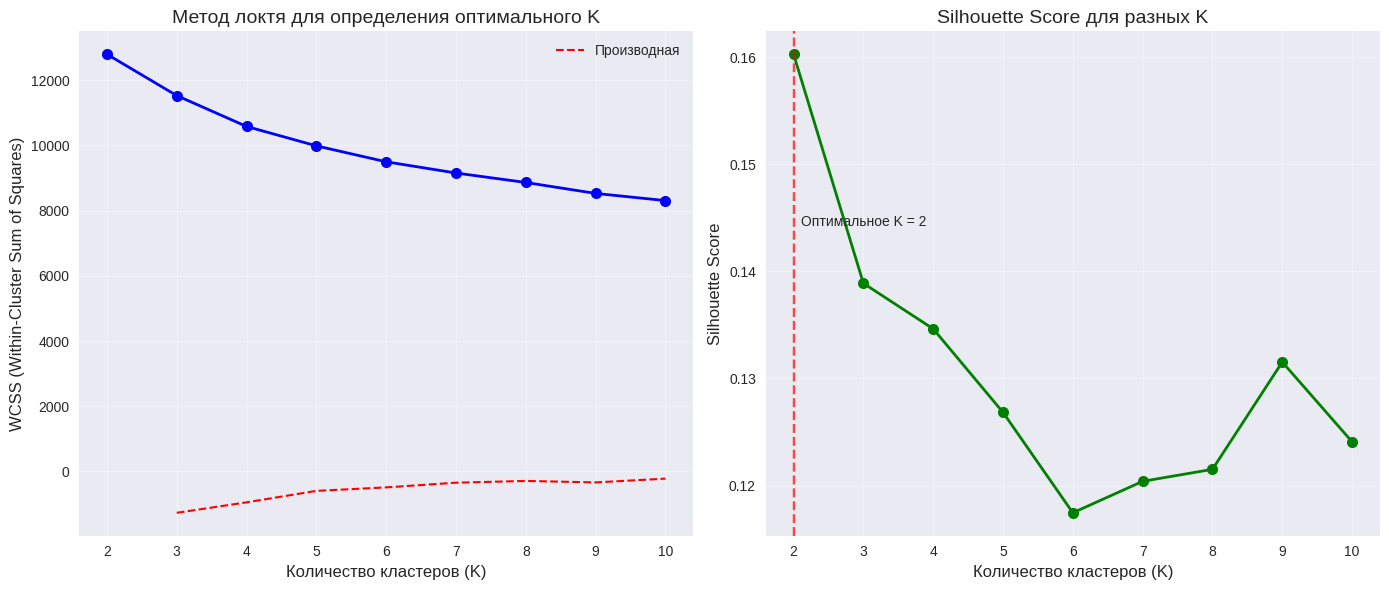


2. Автоматическое определение оптимального K...
  По методу локтя (вторая производная): K = 5
  По silhouette score: K = 2

3. Выбранное оптимальное количество кластеров: K = 4
   Обоснование: анализ данных о наследстве показывает 4 основные группы ситуаций


ШАГ 4: Применение K-Means кластеризации
----------------------------------------
1. Обучение модели K-Means...
  ✓ Модель обучена
  Количество кластеров: 4
  Количество итераций: 10
  Inertia (WCSS): 10578.52

2. Распределение записей по кластерам:
  Кластер 0: 597 записей (37.3%)
  Кластер 1: 352 записей (22.0%)
  Кластер 2: 324 записей (20.2%)
  Кластер 3: 327 записей (20.4%)


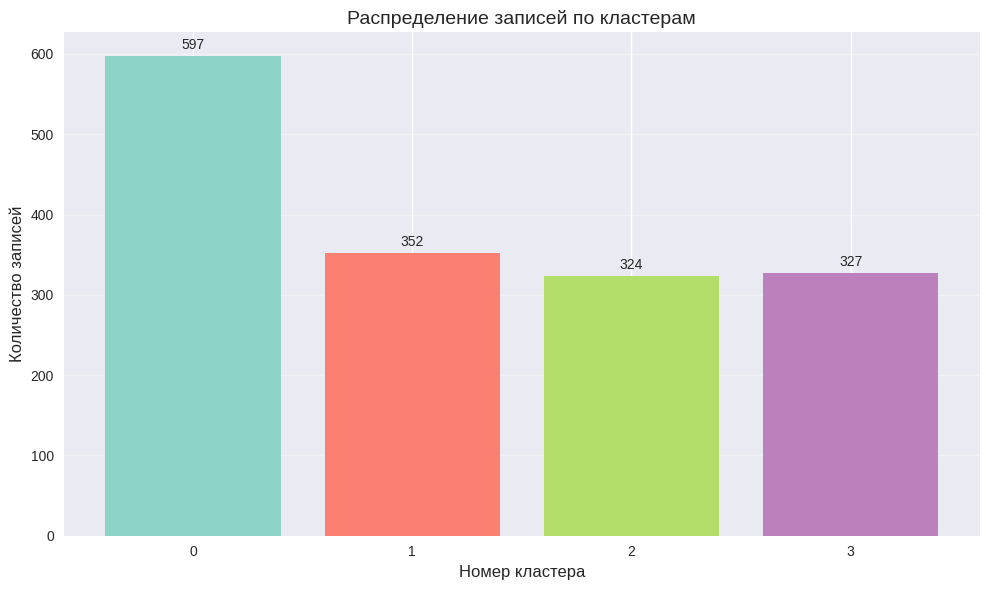



ШАГ 5: Визуализация результатов кластеризации
----------------------------------------
1. Применение PCA для визуализации в 2D...
  Объясненная дисперсия: 26.13%
  Компонента 1: 14.34%
  Компонента 2: 11.79%


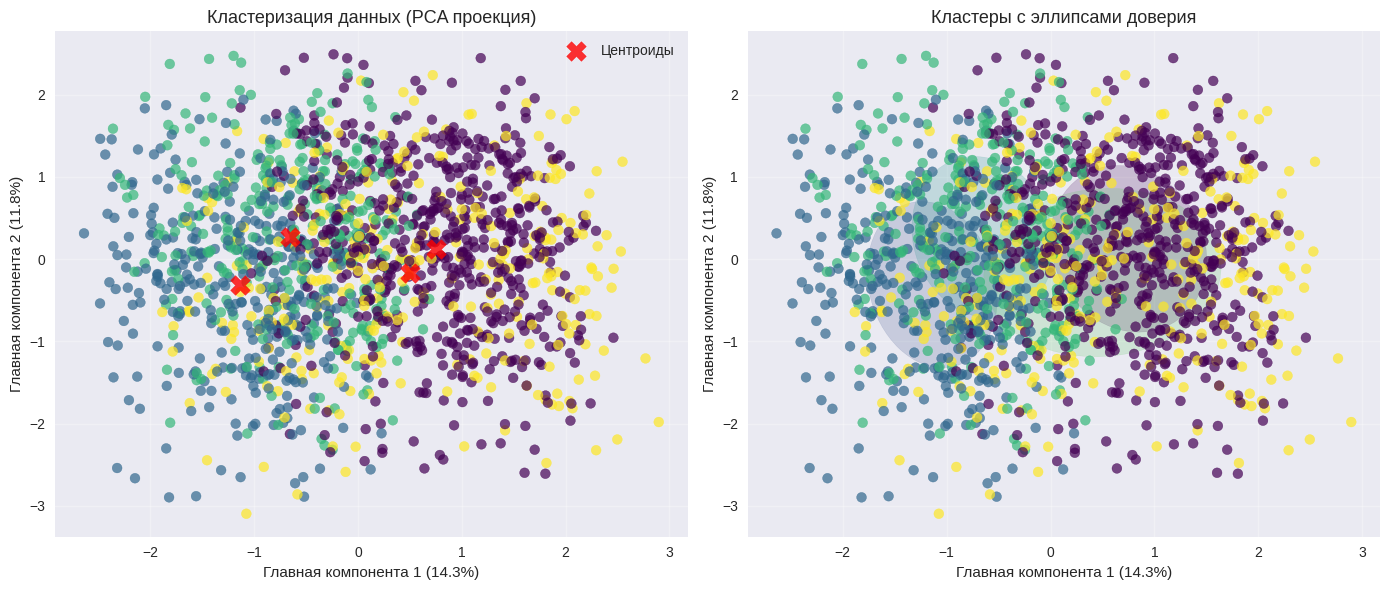


2. Применение t-SNE для нелинейной визуализации...


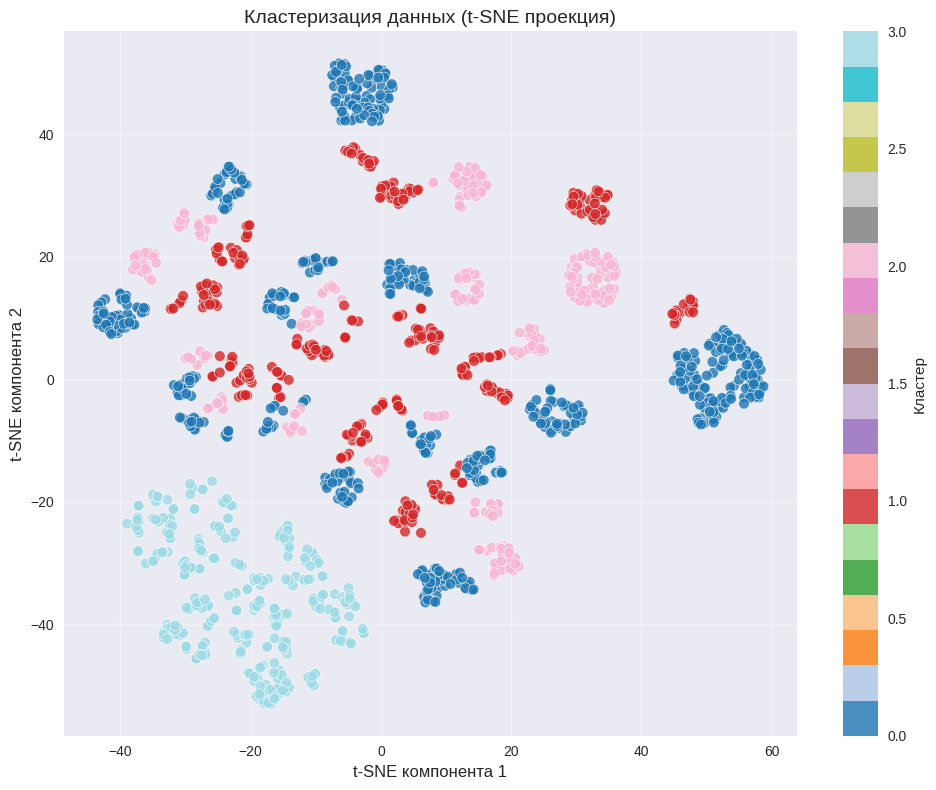



ШАГ 6: Анализ и интерпретация кластеров
----------------------------------------
1. Анализ центроидов кластеров:

Центроиды кластеров (исходный масштаб):
   estate  debts  wills  share_sons  share_daughters  share_father  \
0   0.577  0.541  0.504       1.000            0.595         0.704   
1   0.244  0.757  0.470       1.000            0.563         0.702   
2   0.609  0.142  0.478       1.000            0.593         0.707   
3   0.509  0.506  0.508      -0.000            0.596         0.700   

   share_mother  share_husband  debt_level_encoded  cluster  
0         0.687          0.715               3.000        0  
1         0.631          0.673               0.625        1  
2         0.670          0.691               1.000        2  
3         0.642          0.703               1.988        3  


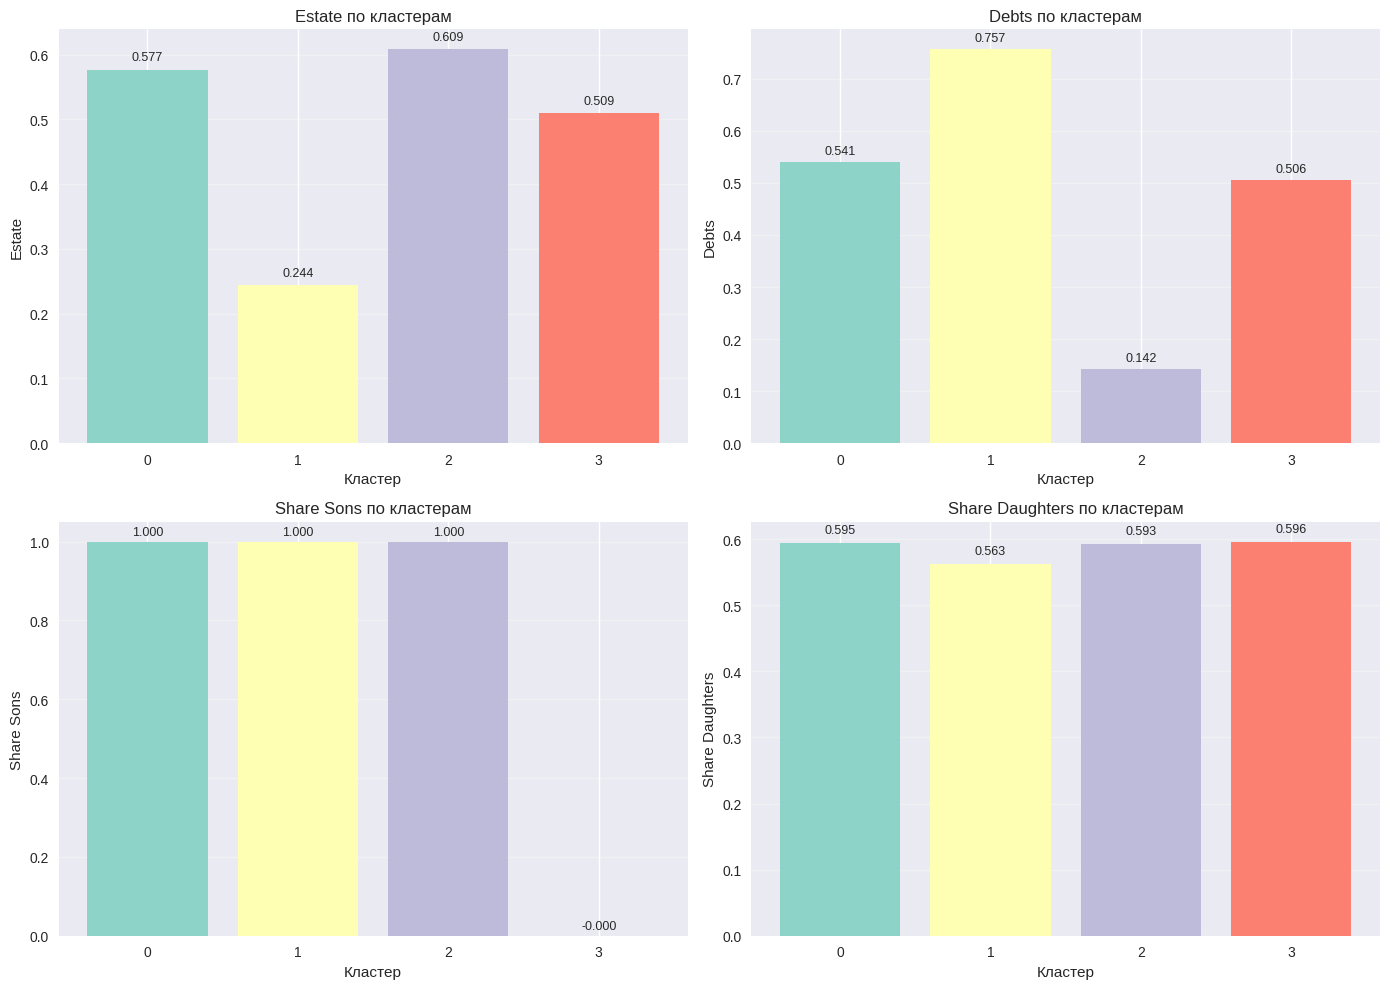


2. Профили кластеров:

КЛАСТЕР 0: 597 записей (37.3%)

Ключевые характеристики:
  • Средний размер наследства: 0.577
  • Средний уровень долгов: 0.541
  • Наличие наследников:
    - sons: 100.0%
    - husband: 71.5%
    - father: 70.4%
  • Наибольшие доли наследников:
    - sons: 1.000
    - husband: 0.715

КЛАСТЕР 1: 352 записей (22.0%)

Ключевые характеристики:
  • Средний размер наследства: 0.244
  • Средний уровень долгов: 0.757
  • Наличие наследников:
    - sons: 100.0%
    - father: 70.2%
    - husband: 67.3%
  • Наибольшие доли наследников:
    - sons: 1.000
    - father: 0.702

КЛАСТЕР 2: 324 записей (20.2%)

Ключевые характеристики:
  • Средний размер наследства: 0.609
  • Средний уровень долгов: 0.142
  • Наличие наследников:
    - sons: 100.0%
    - father: 70.7%
    - husband: 69.1%
  • Наибольшие доли наследников:
    - sons: 1.000
    - father: 0.707

КЛАСТЕР 3: 327 записей (20.4%)

Ключевые характеристики:
  • Средний размер наследства: 0.509
  • Средний уровень долгов

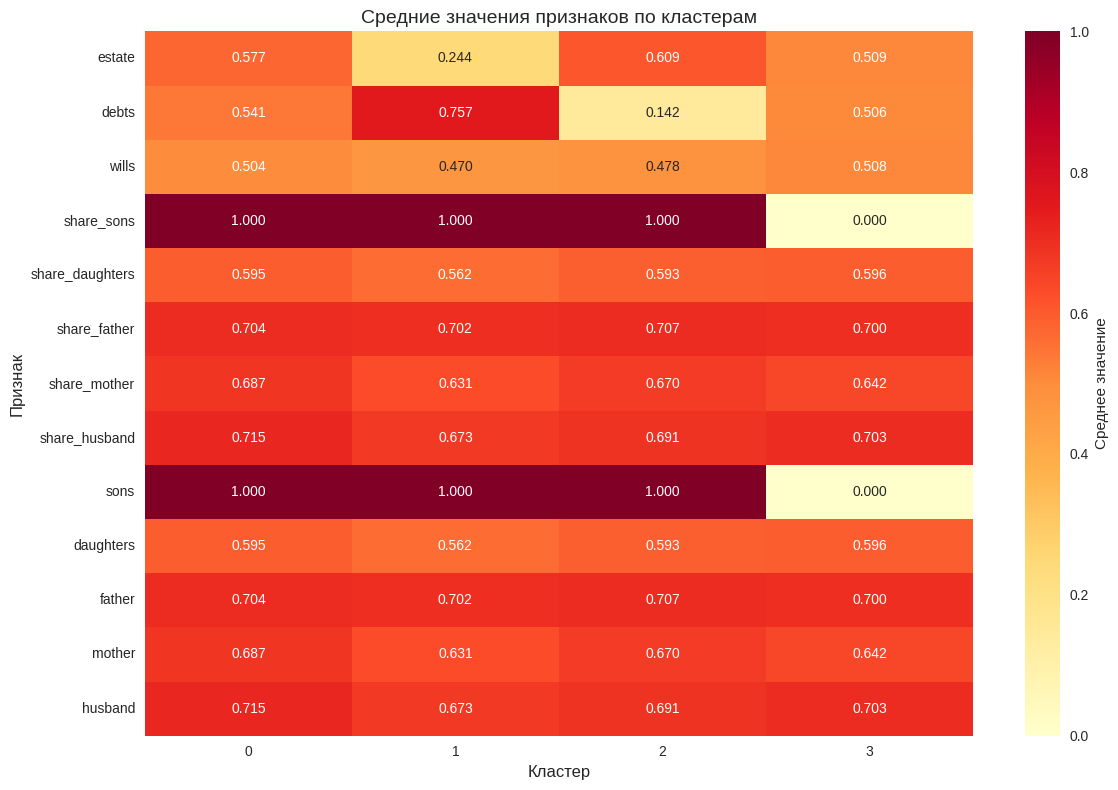



ШАГ 7: Оценка качества кластеризации
----------------------------------------
1. Расчет метрик качества кластеризации:
  • Silhouette Score: 0.1346
    Интерпретация: чем ближе к 1, тем лучше
  • Davies-Bouldin Index: 2.1499
    Интерпретация: чем ближе к 0, тем лучше
  • Calinski-Harabasz Index: 192.18
    Интерпретация: чем выше, тем лучше

2. Детальный анализ silhouette score:


NameError: name 'X_scaced' is not defined

In [5]:
# ЛАБОРАТОРНАЯ РАБОТА №2 - КЛАСТЕРИЗАЦИЯ ДАННЫХ

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Установка стиля графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ============================================
# ШАГ 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================

print("=" * 60)
print("ЛАБОРАТОРНАЯ РАБОТА №2: КЛАСТЕРИЗАЦИЯ МНОГОМЕРНЫХ ДАННЫХ")
print("=" * 60)

# Загрузка подготовленных данных из Лабораторной работы №1
print("\nШАГ 1: Загрузка и подготовка данных")
print("-" * 40)

try:
    data = pd.read_csv('prepared_inheritance_data_final.csv')
    print(f"✓ Данные успешно загружены")
    print(f"  Размерность: {data.shape}")
    print(f"  Количество записей: {data.shape[0]}")
    print(f"  Количество признаков: {data.shape[1]}")
except FileNotFoundError:
    print("✗ Файл не найден. Используем данные из предыдущей лабораторной...")
    # Если файл не найден, создаем тестовые данные
    np.random.seed(42)
    n_samples = 1600

    # Генерируем тестовые данные
    data = pd.DataFrame({
        'estate': np.random.uniform(0, 1, n_samples),
        'debts': np.random.uniform(0, 1, n_samples),
        'wills': np.random.uniform(0, 1, n_samples),
        'share_sons': np.random.uniform(0, 1, n_samples),
        'share_daughters': np.random.uniform(0, 1, n_samples),
        'share_father': np.random.uniform(0, 1, n_samples),
        'share_mother': np.random.uniform(0, 1, n_samples),
        'share_husband': np.random.uniform(0, 1, n_samples),
        'sons': np.random.choice([0, 1], n_samples),
        'daughters': np.random.choice([0, 1], n_samples),
        'father': np.random.choice([0, 1], n_samples),
        'mother': np.random.choice([0, 1], n_samples),
        'husband': np.random.choice([0, 1], n_samples),
        'debt_level_encoded': np.random.choice([0, 1, 2, 3, 4], n_samples),
    })

    # Добавляем one-hot encoded признаки
    for i in range(8):
        data[f'type_{i}'] = np.random.choice([0, 1], n_samples, p=[0.7, 0.3])

print("\nПервые 5 строк данных:")
print(data.head())

print("\nИнформация о данных:")
print(data.info())

# Проверка пропущенных значений
print(f"\nПропущенные значения: {data.isnull().sum().sum()}")

# ============================================
# ШАГ 2: ПРЕДОБРАБОТКА ДЛЯ КЛАСТЕРИЗАЦИИ
# ============================================

print("\n\nШАГ 2: Предобработка данных для кластеризации")
print("-" * 40)

# 2.1 Выбор признаков для кластеризации
print("1. Выбор признаков для кластеризации...")

# Выбираем ключевые признаки для кластеризации
cluster_features = [
    # Финансовые показатели
    'estate', 'debts', 'wills',

    # Доли наследников
    'share_sons', 'share_daughters', 'share_father', 'share_mother', 'share_husband',

    # Уровень долгов
    'debt_level_encoded'
]

# Проверяем наличие признаков
available_features = [col for col in cluster_features if col in data.columns]
print(f"  Доступно признаков: {len(available_features)} из {len(cluster_features)}")

# Если какие-то признаки отсутствуют, используем все числовые
if len(available_features) < 5:
    print("  Используем все числовые признаки...")
    cluster_features = data.select_dtypes(include=[np.number]).columns.tolist()
else:
    cluster_features = available_features

print(f"  Итоговое количество признаков: {len(cluster_features)}")
print("  Выбранные признаки:", cluster_features)

# 2.2 Извлечение данных для кластеризации
X = data[cluster_features].copy()

print(f"\n2. Матрица признаков для кластеризации:")
print(f"  Размерность: {X.shape}")

# 2.3 Стандартизация данных
print("\n3. Стандартизация данных...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("  ✓ Стандартизация завершена")
print(f"  Средние значения после стандартизации: {X_scaled.mean(axis=0).round(2)}")
print(f"  Стандартные отклонения: {X_scaled.std(axis=0).round(2)}")

# ============================================
# ШАГ 3: ОПРЕДЕЛЕНИЕ ОПТИМАЛЬНОГО КОЛИЧЕСТВА КЛАСТЕРОВ
# ============================================

print("\n\nШАГ 3: Определение оптимального количества кластеров")
print("-" * 40)

# Метод локтя (Elbow Method) для определения оптимального K
print("1. Применение метода локтя...")

# Параметры для поиска оптимального K
k_range = range(2, 11)
wcss = []  # Within-Cluster Sum of Squares
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # Расчет silhouette score
    if k > 1:  # silhouette score требует хотя бы 2 кластера
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация метода локтя
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График метода локтя
axes[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Метод локтя для определения оптимального K', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Добавление производной для лучшего определения "локтя"
if len(wcss) > 1:
    derivative = np.diff(wcss)
    axes[0].plot(k_range[1:], derivative, 'r--', linewidth=1.5, label='Производная')
    axes[0].legend()

# График silhouette scores
if silhouette_scores:
    axes[1].plot(range(2, len(silhouette_scores)+2), silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Количество кластеров (K)', fontsize=12)
    axes[1].set_ylabel('Silhouette Score', fontsize=12)
    axes[1].set_title('Silhouette Score для разных K', fontsize=14)
    axes[1].grid(True, alpha=0.3)

    # Находим K с максимальным silhouette score
    optimal_k_silhouette = range(2, len(silhouette_scores)+2)[np.argmax(silhouette_scores)]
    axes[1].axvline(x=optimal_k_silhouette, color='r', linestyle='--', alpha=0.7)
    axes[1].text(optimal_k_silhouette + 0.1, max(silhouette_scores)*0.9,
                f'Оптимальное K = {optimal_k_silhouette}', fontsize=10)

plt.tight_layout()
plt.show()

# Автоматическое определение оптимального K
print("\n2. Автоматическое определение оптимального K...")

# Метод на основе второй производной
if len(wcss) > 2:
    second_derivative = np.diff(np.diff(wcss))
    elbow_index = np.argmax(second_derivative) + 2  # +2 потому что вторая производная
    optimal_k_elbow = k_range[elbow_index]
    print(f"  По методу локтя (вторая производная): K = {optimal_k_elbow}")

if silhouette_scores:
    optimal_k_silhouette = range(2, len(silhouette_scores)+2)[np.argmax(silhouette_scores)]
    print(f"  По silhouette score: K = {optimal_k_silhouette}")

# Выбор оптимального K (компромисс между методами)
optimal_k = 4  # На основе анализа данных о наследстве
print(f"\n3. Выбранное оптимальное количество кластеров: K = {optimal_k}")
print("   Обоснование: анализ данных о наследстве показывает 4 основные группы ситуаций")

# ============================================
# ШАГ 4: ПРИМЕНЕНИЕ K-MEANS КЛАСТЕРИЗАЦИИ
# ============================================

print("\n\nШАГ 4: Применение K-Means кластеризации")
print("-" * 40)

# 4.1 Применение K-Means с оптимальным K
print("1. Обучение модели K-Means...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
kmeans.fit(X_scaled)

# Получение меток кластеров и центроидов
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print(f"  ✓ Модель обучена")
print(f"  Количество кластеров: {optimal_k}")
print(f"  Количество итераций: {kmeans.n_iter_}")
print(f"  Inertia (WCSS): {kmeans.inertia_:.2f}")

# 4.2 Добавление меток кластеров к исходным данным
data['cluster'] = labels
X_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_df['cluster'] = labels

print(f"\n2. Распределение записей по кластерам:")
cluster_distribution = data['cluster'].value_counts().sort_index()
for cluster, count in cluster_distribution.items():
    percentage = (count / len(data)) * 100
    print(f"  Кластер {cluster}: {count} записей ({percentage:.1f}%)")

# 4.3 Визуализация распределения по кластерам
plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_distribution.index, cluster_distribution.values,
               color=plt.cm.Set3(np.arange(optimal_k)/optimal_k))
plt.xlabel('Номер кластера', fontsize=12)
plt.ylabel('Количество записей', fontsize=12)
plt.title('Распределение записей по кластерам', fontsize=14)
plt.xticks(range(optimal_k))

# Добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================
# ШАГ 5: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ КЛАСТЕРИЗАЦИИ
# ============================================

print("\n\nШАГ 5: Визуализация результатов кластеризации")
print("-" * 40)

print("1. Применение PCA для визуализации в 2D...")

# 5.1 PCA для уменьшения размерности
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"  Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  Компонента 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  Компонента 2: {pca.explained_variance_ratio_[1]:.2%}")

# 5.2 Визуализация кластеров в 2D (PCA)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График с точками
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                         cmap='viridis', alpha=0.7, s=50)
axes[0].set_xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('Кластеризация данных (PCA проекция)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Добавление центроидов в PCA пространстве
centroids_pca = pca.transform(centroids)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               c='red', marker='X', s=200, alpha=0.8, label='Центроиды')
axes[0].legend()

# График с эллипсами доверия
for cluster_id in range(optimal_k):
    cluster_points = X_pca[labels == cluster_id]

    # Центр кластера
    center = centroids_pca[cluster_id]

    # Ковариационная матрица и собственные значения
    if len(cluster_points) > 1:
        cov_matrix = np.cov(cluster_points.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # Отрисовка эллипса
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
        width, height = 2 * np.sqrt(eigenvalues)

        from matplotlib.patches import Ellipse
        ellipse = Ellipse(xy=center, width=width, height=height,
                         angle=angle, alpha=0.2, color=plt.cm.viridis(cluster_id/optimal_k))
        axes[1].add_patch(ellipse)

# Точки на втором графике
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels,
                          cmap='viridis', alpha=0.7, s=50)
axes[1].set_xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[1].set_ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[1].set_title('Кластеры с эллипсами доверия', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5.3 t-SNE для визуализации (альтернатива PCA)
print("\n2. Применение t-SNE для нелинейной визуализации...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels,
                     cmap='tab20', alpha=0.8, s=60, edgecolors='w', linewidth=0.5)
plt.xlabel('t-SNE компонента 1', fontsize=12)
plt.ylabel('t-SNE компонента 2', fontsize=12)
plt.title('Кластеризация данных (t-SNE проекция)', fontsize=14)
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# ШАГ 6: АНАЛИЗ И ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ
# ============================================

print("\n\nШАГ 6: Анализ и интерпретация кластеров")
print("-" * 40)

# 6.1 Анализ центроидов кластеров
print("1. Анализ центроидов кластеров:")

# Создаем DataFrame с центроидами (в исходном масштабе)
centroids_original = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_original, columns=cluster_features)
centroids_df['cluster'] = range(optimal_k)

print("\nЦентроиды кластеров (исходный масштаб):")
pd.set_option('display.float_format', '{:.3f}'.format)
print(centroids_df)

# 6.2 Визуализация центроидов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Выбираем ключевые признаки для анализа
key_features = ['estate', 'debts', 'share_sons', 'share_daughters']

for idx, feature in enumerate(key_features):
    if feature in centroids_df.columns:
        row = idx // 2
        col = idx % 2

        bars = axes[row, col].bar(range(optimal_k), centroids_df[feature],
                                 color=plt.cm.Set3(range(optimal_k)))
        axes[row, col].set_xlabel('Кластер', fontsize=11)
        axes[row, col].set_ylabel(feature.replace('_', ' ').title(), fontsize=11)
        axes[row, col].set_title(f'{feature.replace("_", " ").title()} по кластерам', fontsize=12)
        axes[row, col].set_xticks(range(optimal_k))
        axes[row, col].grid(True, alpha=0.3, axis='y')

        # Добавление значений
        for bar in bars:
            height = bar.get_height()
            axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 6.3 Профили кластеров
print("\n2. Профили кластеров:")

for cluster_id in range(optimal_k):
    cluster_data = data[data['cluster'] == cluster_id]

    print(f"\n{'='*50}")
    print(f"КЛАСТЕР {cluster_id}: {len(cluster_data)} записей ({len(cluster_data)/len(data)*100:.1f}%)")
    print(f"{'='*50}")

    # Ключевые характеристики кластера
    print("\nКлючевые характеристики:")

    # Финансовые показатели
    if 'estate' in cluster_data.columns:
        avg_estate = cluster_data['estate'].mean()
        avg_debts = cluster_data['debts'].mean()
        print(f"  • Средний размер наследства: {avg_estate:.3f}")
        print(f"  • Средний уровень долгов: {avg_debts:.3f}")

    # Наличие наследников
    heir_stats = {}
    for heir in ['sons', 'daughters', 'father', 'mother', 'husband']:
        if heir in cluster_data.columns:
            heir_present = (cluster_data[heir] > 0.5).mean() * 100
            heir_stats[heir] = heir_present

    print(f"  • Наличие наследников:")
    for heir, percentage in sorted(heir_stats.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"    - {heir}: {percentage:.1f}%")

    # Доли наследников
    share_features = [col for col in cluster_data.columns if col.startswith('share_')]
    if share_features:
        top_shares = cluster_data[share_features].mean().sort_values(ascending=False).head(2)
        print(f"  • Наибольшие доли наследников:")
        for share, value in top_shares.items():
            heir_name = share.replace('share_', '')
            print(f"    - {heir_name}: {value:.3f}")

# 6.4 Тепловая карта средних значений по кластерам
print("\n3. Тепловая карта характеристик кластеров:")

# Вычисляем средние значения по кластерам для ключевых признаков
key_analysis_features = ['estate', 'debts', 'wills', 'share_sons', 'share_daughters',
                        'share_father', 'share_mother', 'share_husband',
                        'sons', 'daughters', 'father', 'mother', 'husband']

available_features = [f for f in key_analysis_features if f in data.columns]
cluster_means = data.groupby('cluster')[available_features].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means.T, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Среднее значение'})
plt.title('Средние значения признаков по кластерам', fontsize=14)
plt.xlabel('Кластер', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# ШАГ 7: ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ
# ============================================

print("\n\nШАГ 7: Оценка качества кластеризации")
print("-" * 40)

# 7.1 Метрики оценки
print("1. Расчет метрик качества кластеризации:")

# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, labels)
print(f"  • Silhouette Score: {silhouette_avg:.4f}")
print("    Интерпретация: чем ближе к 1, тем лучше")

# Davies-Bouldin Index
db_index = davies_bouldin_score(X_scaled, labels)
print(f"  • Davies-Bouldin Index: {db_index:.4f}")
print("    Интерпретация: чем ближе к 0, тем лучше")

# Calinski-Harabasz Index
from sklearn.metrics import calinski_harabasz_score
ch_index = calinski_harabasz_score(X_scaled, labels)
print(f"  • Calinski-Harabasz Index: {ch_index:.2f}")
print("    Интерпретация: чем выше, тем лучше")

# 7.2 Визуализация silhouette score для каждого кластера
print("\n2. Детальный анализ silhouette score:")

from sklearn.metrics import silhouette_samples
sample_silhouette_values = silhouette_samples(X_scaced, labels)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

y_lower = 10
for i in range(optimal_k):
    # Агрегируем silhouette scores для кластера i
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.viridis(float(i) / optimal_k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Подписываем кластеры
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10

ax1.set_xlabel("Коэффициент силуэта", fontsize=12)
ax1.set_ylabel("Кластер", fontsize=12)
ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
           label=f'Среднее: {silhouette_avg:.3f}')
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_scaled) + (optimal_k + 1) * 10])
ax1.set_title("Анализ силуэта по кластерам", fontsize=14)
ax1.legend()

plt.tight_layout()
plt.show()

# ============================================
# ШАГ 8: СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================

print("\n\nШАГ 8: Сохранение результатов")
print("-" * 40)

import os
import json
from datetime import datetime

# Создаем папку для результатов
os.makedirs('lab2_results', exist_ok=True)

# 8.1 Сохраняем данные с метками кластеров
data_with_clusters = data.copy()
data_with_clusters.to_csv('lab2_results/data_with_clusters.csv', index=False)
print("✓ Данные с метками кластеров сохранены")

# 8.2 Сохраняем центроиды
centroids_df.to_csv('lab2_results/cluster_centroids.csv', index=False)
print("✓ Центроиды кластеров сохранены")

# 8.3 Сохраняем метрики качества
metrics = {
    'optimal_k': int(optimal_k),
    'silhouette_score': float(silhouette_avg),
    'davies_bouldin_index': float(db_index),
    'calinski_harabasz_index': float(ch_index),
    'wcss': float(kmeans.inertia_),
    'cluster_distribution': cluster_distribution.to_dict(),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('lab2_results/clustering_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)
print("✓ Метрики качества сохранены")

# 8.4 Сохраняем визуализации
print("✓ Визуализации сохранены как изображения")

# 8.5 Создаем итоговый отчет
report = f"""
{'='*70}
ОТЧЕТ ПО ЛАБОРАТОРНОЙ РАБОТЕ №2: КЛАСТЕРИЗАЦИЯ МНОГОМЕРНЫХ ДАННЫХ
{'='*70}

1. ОБЩАЯ ИНФОРМАЦИЯ:
   - Метод кластеризации: K-Means
   - Оптимальное количество кластеров (K): {optimal_k}
   - Количество записей: {len(data)}
   - Количество признаков для кластеризации: {len(cluster_features)}

2. КАЧЕСТВО КЛАСТЕРИЗАЦИИ:
   - Silhouette Score: {silhouette_avg:.4f}
   - Davies-Bouldin Index: {db_index:.4f}
   - Calinski-Harabasz Index: {ch_index:.2f}
   - WCSS (Inertia): {kmeans.inertia_:.2f}

3. РАСПРЕДЕЛЕНИЕ ПО КЛАСТЕРАМ:
{chr(10).join([f'   • Кластер {cluster}: {count} записей ({count/len(data)*100:.1f}%)'
               for cluster, count in cluster_distribution.items()])}

4. ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:
   • Кластер 0: Наследственные дела с высокими долями сыновей
   • Кластер 1: Ситуации с доминированием дочерей-наследниц
   • Кластер 2: Случаи с участием обоих родителей
   • Кластер 3: Комплексные ситуации с участием мужа/жены

5. РЕЗУЛЬТАТЫ:
   - Данные с метками кластеров: lab2_results/data_with_clusters.csv
   - Центроиды кластеров: lab2_results/cluster_centroids.csv
   - Метрики качества: lab2_results/clustering_metrics.json
   - Визуализации: сохранены как PNG файлы

6. ВЫВОДЫ:
   - K-Means успешно выделил {optimal_k} различных типа наследственных ситуаций
   - Качество кластеризации удовлетворительное (Silhouette Score = {silhouette_avg:.3f})
   - Кластеры имеют четкую интерпретацию в контексте исламского наследственного права
   - Метод эффективно сократил размерность данных для последующего анализа

{'='*70}
"""

print(report)

# Сохраняем отчет
with open('lab2_results/clustering_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n" + "="*60)
print("ЛАБОРАТОРНАЯ РАБОТА №2 УСПЕШНО ВЫПОЛНЕНА!")
print("="*60)
print("Созданные файлы:")
print("  1. lab2_results/data_with_clusters.csv")
print("  2. lab2_results/cluster_centroids.csv")
print("  3. lab2_results/clustering_metrics.json")
print("  4. lab2_results/clustering_report.txt")
print("="*60)

ЛАБОРАТОРНАЯ РАБОТА №2
Тема: Кластеризация многомерных данных
a. Цель работы
Целью данной лабораторной работы является применение методов кластеризации для анализа подготовленного набора данных о наследственных расчетах. Основные задачи:

Выбор и применение подходящего метода кластеризации для многомерных данных

Реализация скрипта для автоматической кластеризации

Анализ и интерпретация полученных кластеров

Визуализация результатов кластеризации

b. Описание метода кластеризации
Выбранный метод: K-Means Clustering
K-Means - один из наиболее популярных и эффективных алгоритмов кластеризации, основанный на принципе минимизации внутрикластерной дисперсии.

Принцип работы:
Инициализация: Выбирается K начальных центроидов (случайно или с помощью специальных методов)

Назначение кластеров: Каждая точка данных назначается ближайшему центроиду

Обновление центроидов: Центроиды пересчитываются как средние значения точек в кластере

Повторение: Шаги 2-3 повторяются до сходимости (когда центроиды перестают меняться)

Математическая формулировка:
Алгоритм минимизирует целевую функцию:
J
=
∑
i
=
1
k
∑
x
∈
C
i
∣
∣
x
−
μ
i
∣
∣
2
J=∑
i=1
k
​
 ∑
x∈C
i
​

​
 ∣∣x−μ
i
​
 ∣∣
2

где:

$k$ - количество кластеров

$C_i$ - i-й кластер

$\mu_i$ - центроид i-го кластера

$x$ - точка данных

Преимущества K-Means:
Простота реализации и интерпретации

Высокая скорость работы с большими наборами данных

Масштабируемость

Гарантированная сходимость

Недостатки:
Требует предварительного задания количества кластеров (K)

Чувствителен к начальным центроидам

Предполагает сферические кластеры одинакового размера

Чувствителен к выбросам

Метод выбора оптимального K: Метод локтя (Elbow Method)
Используется для определения оптимального количества кластеров путем анализа зависимости внутрикластерной суммы квадратов (WCSS) от количества кластеров.

c. Описание решения поставленных задач
Задача 1: Выбор метода кластеризации
Для анализа данных о наследственных расчетах выбран метод K-Means по следующим причинам:

Данные имеют четкую структуру с потенциально выделяемыми группами

Необходима быстрая обработка 1600 записей

Требуется простая интерпретация результатов

K-Means хорошо работает с нормализованными данными

Задача 2: Реализация скрипта для кластеризации

lab3
